<a href="https://colab.research.google.com/github/Erkgrcsll/sepsis-prediction-mimiciv/blob/main/MIMIC_IV_for_Sepsis_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORT LIBRARY
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from google.colab import files

pd.set_option('display.max_columns', None)

sns.set_style('whitegrid')



In [ ]:
# LOAD DATASET
# ==========================================

uploaded = files.upload()

df = pd.read_csv("sepsis_icu_synthetic.csv")
df.head()

Saving sepsis_icu_synthetic.csv to sepsis_icu_synthetic (1).csv


,subject_id,age,gender,weight_kg,height_cm,bmi,ethnicity,insurance,hr_mean,hr_max,hr_min,hr_std,sbp_mean,sbp_max,sbp_min,sbp_std,dbp_mean,dbp_max,dbp_min,dbp_std,map_mean,temp_celsius_mean,temp_celsius_max,temp_celsius_min,temp_celsius_std,spo2_mean,spo2_min,spo2_max,spo2_std,respiratory_rate_mean,respiratory_rate_max,respiratory_rate_min,respiratory_rate_std,wbc,lactate_mmol,creatinine,platelet_count,bilirubin_total,glucose,ph_arterial,pao2_fio2_ratio,inr,sodium,potassium,chloride,bicarbonate,hematocrit,hemoglobin,diabetes,hypertension,chf,copd,chronic_kidney_disease,liver_disease,immunosuppression,cad,atrial_fibrillation,cancer_active,vasopressors_flag,mechanical_ventilation,fio2_percent,antibiotics_24h,fluids_ml_24h,sedation_score,vasopressor_dose_mcg_kg_min,insulin_infusion_flag,sofa_score,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,hospital_admit_source,icu_admit_time_hour,day_of_week,readmission_30day,sepsis_label
0,37464,72,M,99.5,160.6,38.6,Black,Medicare,83.0,98.7,73.7,7.4,113.8,123.2,94.5,11.1,65.6,75.1,52.5,8.8,NaN,37.0,37.2,36.4,0.39,94.4,92.8,94.7,1.47,23.0,29.0,21.0,1.2,6.722391,2.40,4.60,NaN,0.51,NaN,7.347,56.6,1.57,NaN,3.82,111.9,16.5,44.2,14.30,1,1,1,1,1,0,0,1,0,0,1,1,58.8,1,1688.0,-4.0,1.505,0,12,47.9,2,1,12,27.0,OR,15,2,1,1
1,34024,62,M,101.2,164.5,37.4,Other,Private,97.5,105.8,87.9,4.0,110.9,130.9,99.0,6.9,64.5,79.4,51.7,4.7,80.0,37.6,38.2,37.4,0.42,95.8,93.7,96.6,2.06,12.0,18.0,8.0,3.0,10.621813,1.46,2.19,217.0,0.45,112.0,7.365,95.8,NaN,136.0,4.44,93.3,23.0,28.2,9.29,0,0,0,0,0,0,0,0,0,0,1,1,69.4,0,639.0,1.0,1.933,0,12,35.0,1,1,6,21.5,Transfer,21,2,0,0
2,65291,74,M,64.0,167.2,22.9,White,Private,100.6,105.8,91.4,7.2,119.5,138.6,108.0,10.4,65.4,79.3,62.3,8.8,83.4,37.0,37.8,36.4,0.37,96.5,94.4,97.7,1.37,14.0,18.0,12.0,0.5,10.234761,0.67,2.53,327.0,1.10,91.0,7.441,96.5,NaN,135.3,NaN,NaN,25.2,22.7,7.73,0,1,1,0,1,0,0,0,1,0,0,1,25.4,0,953.0,-4.0,0.000,0,8,29.0,1,1,11,46.7,ED,19,6,0,0
3,79118,87,M,75.1,180.5,23.0,White,Medicare,95.5,114.7,85.1,3.6,132.5,151.3,116.1,7.3,81.5,94.7,66.6,3.8,98.5,37.5,38.1,36.9,0.19,97.0,93.9,97.7,1.21,17.0,21.0,13.0,2.1,10.065276,0.60,2.23,255.0,0.52,214.0,7.408,97.0,NaN,136.0,4.40,100.9,23.1,30.8,10.55,1,1,0,0,0,0,0,0,0,0,0,1,22.1,0,591.0,-1.0,0.000,0,9,35.6,1,1,7,1.7,ED,8,2,0,0
4,34897,61,M,52.5,158.4,NaN,Hispanic,Private,86.7,106.7,73.2,11.5,102.0,117.5,86.7,9.0,59.7,72.0,56.5,9.4,73.8,37.2,37.5,36.6,0.30,99.0,98.1,99.1,1.28,13.0,17.0,9.0,1.2,18.258126,1.03,1.94,NaN,NaN,190.0,7.417,99.0,1.07,NaN,2.57,98.6,25.0,37.4,12.58,1,0,0,0,0,1,0,0,0,0,0,1,22.9,0,653.0,-1.0,0.000,1,7,34.6,1,1,8,64.0,Transfer,9,2,0,0


In [ ]:
# CHECK DATASET DIMENSION
# ==========================================

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 5000
Columns : 77


In [ ]:
# CHECK DATA TYPE
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 77 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   subject_id                   5000 non-null   int64  
 1   age                          5000 non-null   int64  
 2   gender                       5000 non-null   object 
 3   weight_kg                    5000 non-null   float64
 4   height_cm                    5000 non-null   float64
 5   bmi                          4749 non-null   float64
 6   ethnicity                    5000 non-null   object 
 7   insurance                    5000 non-null   object 
 8   hr_mean                      5000 non-null   float64
 9   hr_max                       5000 non-null   float64
 10  hr_min                       5000 non-null   float64
 11  hr_std                       5000 non-null   float64
 12  sbp_mean                     5000 non-null   float64
 13  sbp_max           

In [ ]:
# MISSING VALUE ANALYSIS
# ==========================================

missing = pd.DataFrame({

    'Missing Count': df.isnull().sum(),

    'Missing Percentage':
    round(df.isnull().mean()*100,2)

})

missing.sort_values(
    by='Missing Percentage',
    ascending=False
)

,Missing Count,Missing Percentage
glucose,565,11.30
inr,558,11.16
bilirubin_total,557,11.14
hematocrit,554,11.08
platelet_count,550,11.00
...,...,...
hospital_admit_source,0,0.00
icu_admit_time_hour,0,0.00
day_of_week,0,0.00
readmission_30day,0,0.00


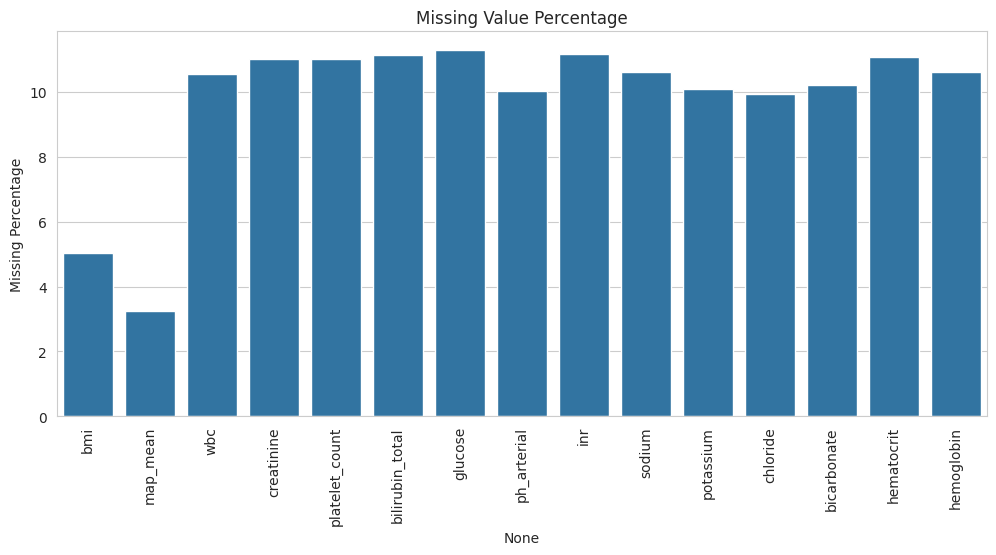

In [ ]:
# VISUALIZE MISSING VALUE
# ==========================================

missing_plot = missing[
    missing['Missing Count'] > 0
]

plt.figure(figsize=(12,5))

sns.barplot(
    x=missing_plot.index,
    y=missing_plot['Missing Percentage']
)

plt.xticks(rotation=90)

plt.title(
    'Missing Value Percentage'
)

plt.show()

In [ ]:
# DUPLICATE CHECK
# ==========================================

duplicate_count = df.duplicated().sum()

print(
    "Duplicate Rows :",
    duplicate_count
)

Duplicate Rows : 0


In [ ]:
# TARGET DISTRIBUTION ANALYSIS
# ==========================================

df['sepsis_label'].value_counts()

,count
sepsis_label,
0,4250
1,750


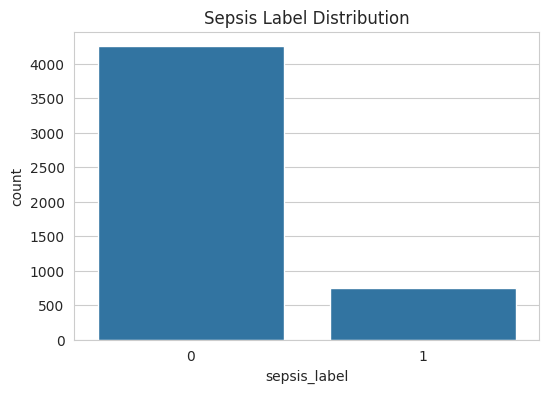

In [ ]:
# TARGET DISTRIBUTION VISUALIZATION
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='sepsis_label',
    data=df
)

plt.title(
    'Sepsis Label Distribution'
)

plt.show()

In [ ]:
# NUMERICAL FEATURES IDENTIFICATION
# ==========================================

num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

num_cols

Index(['subject_id', 'age', 'weight_kg', 'height_cm', 'bmi', 'hr_mean',
       'hr_max', 'hr_min', 'hr_std', 'sbp_mean', 'sbp_max', 'sbp_min',
       'sbp_std', 'dbp_mean', 'dbp_max', 'dbp_min', 'dbp_std', 'map_mean',
       'temp_celsius_mean', 'temp_celsius_max', 'temp_celsius_min',
       'temp_celsius_std', 'spo2_mean', 'spo2_min', 'spo2_max', 'spo2_std',
       'respiratory_rate_mean', 'respiratory_rate_max', 'respiratory_rate_min',
       'respiratory_rate_std', 'wbc', 'lactate_mmol', 'creatinine',
       'platelet_count', 'bilirubin_total', 'glucose', 'ph_arterial',
       'pao2_fio2_ratio', 'inr', 'sodium', 'potassium', 'chloride',
       'bicarbonate', 'hematocrit', 'hemoglobin', 'diabetes', 'hypertension',
       'chf', 'copd', 'chronic_kidney_disease', 'liver_disease',
       'immunosuppression', 'cad', 'atrial_fibrillation', 'cancer_active',
       'vasopressors_flag', 'mechanical_ventilation', 'fio2_percent',
       'antibiotics_24h', 'fluids_ml_24h', 'sedation_score',
   

In [ ]:
# DESCRIPTIVE STATISTICS
# ==========================================

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
subject_id,5000.0,55017.285200,14621.769430,30009.0,42132.5,55733.5,67780.250,79966.0
age,5000.0,64.271600,14.287136,18.0,55.0,65.0,74.000,89.0
weight_kg,5000.0,74.882440,18.609579,45.0,63.5,73.7,84.400,241.9
height_cm,5000.0,170.042780,9.498858,150.0,163.4,170.1,176.625,190.0
bmi,4749.0,25.835965,5.876215,12.5,21.6,25.6,29.600,48.4
...,...,...,...,...,...,...,...,...
icu_los_hours,5000.0,48.171620,48.757138,1.0,13.6,33.5,66.400,500.0
icu_admit_time_hour,5000.0,12.885800,6.481200,0.0,7.0,14.0,19.000,23.0
day_of_week,5000.0,3.760800,1.931613,1.0,2.0,4.0,5.000,7.0
readmission_30day,5000.0,0.053800,0.225645,0.0,0.0,0.0,0.000,1.0


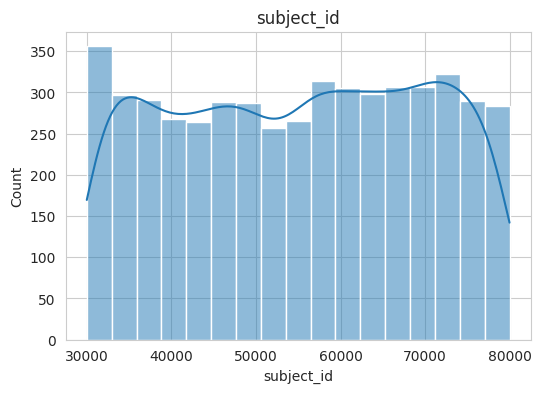

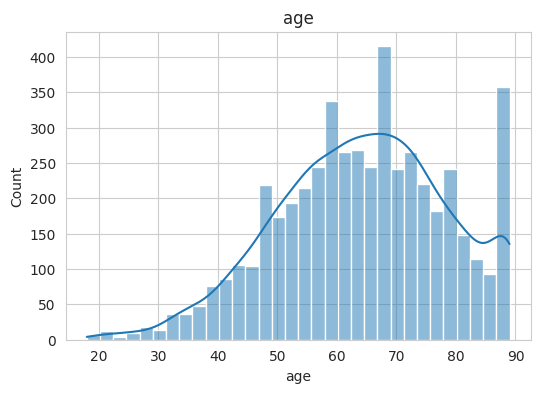

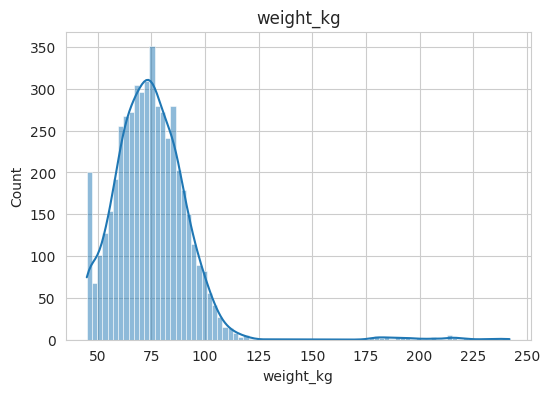

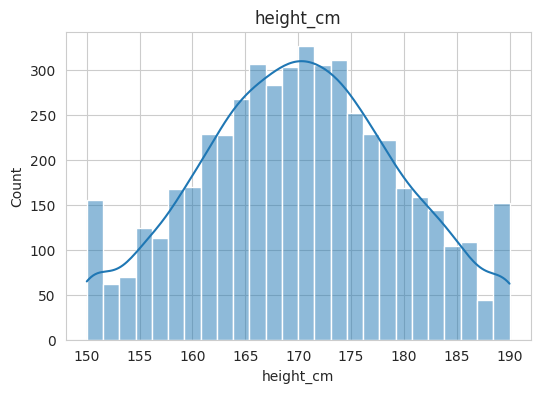

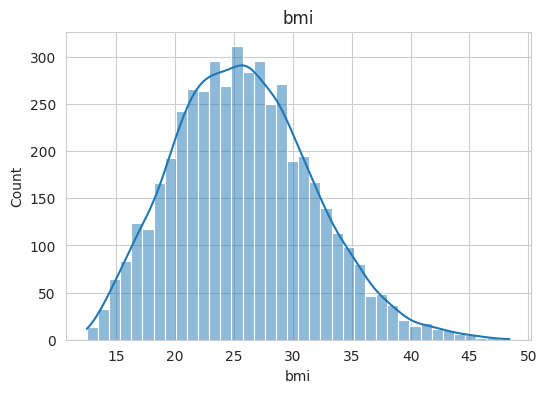

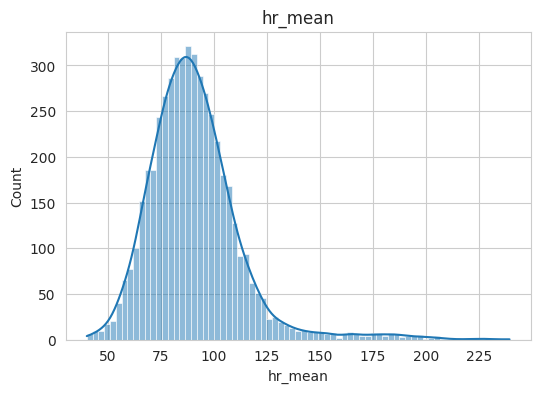

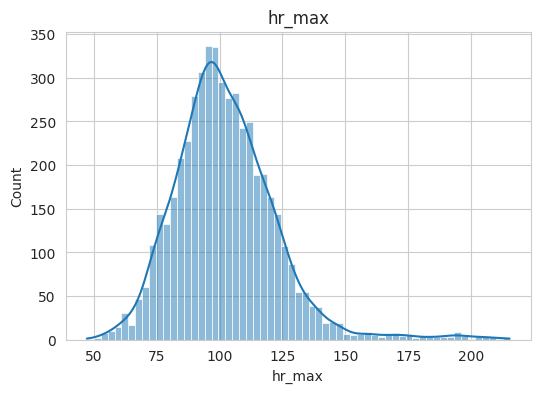

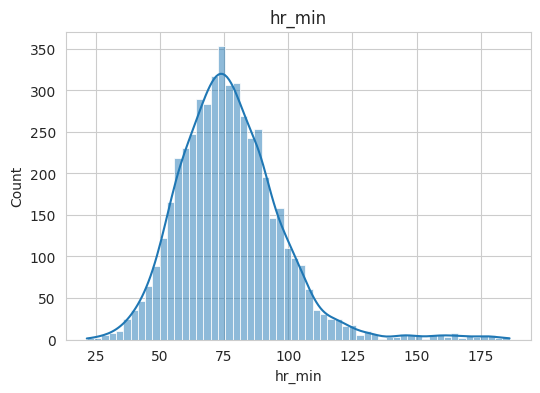

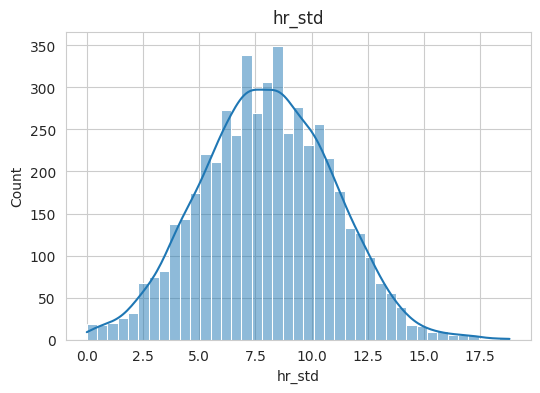

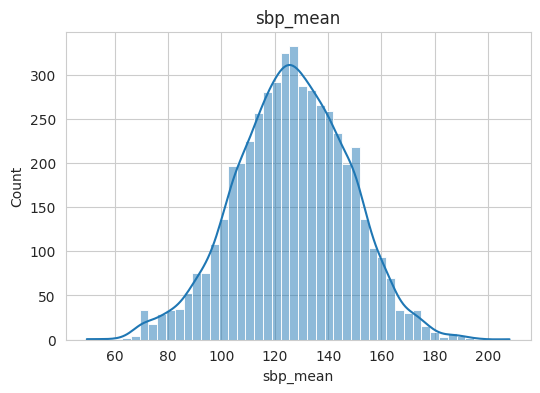

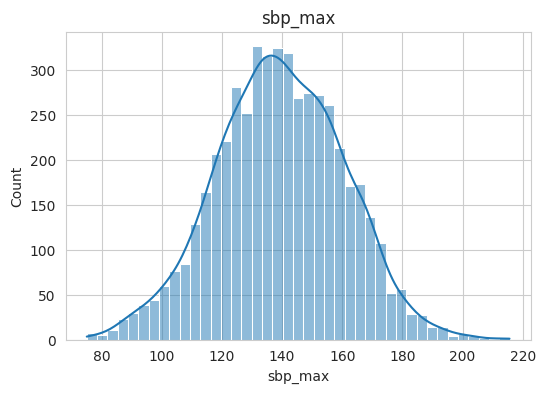

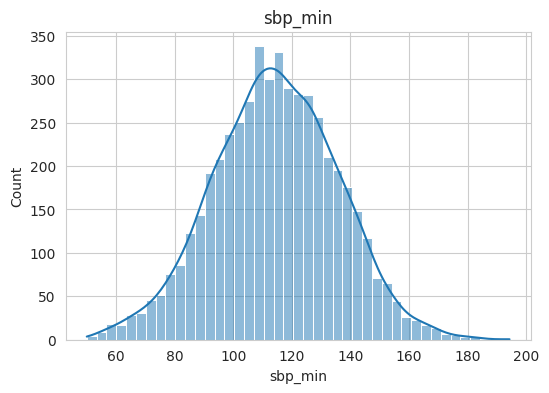

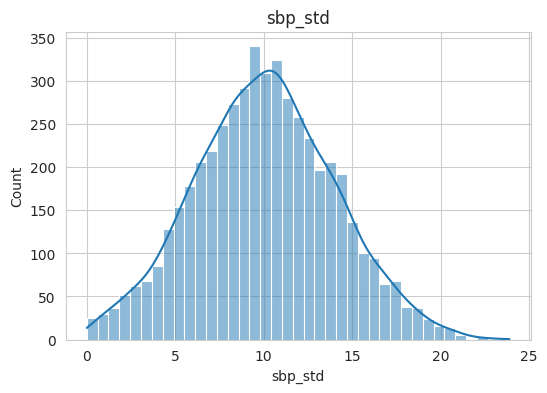

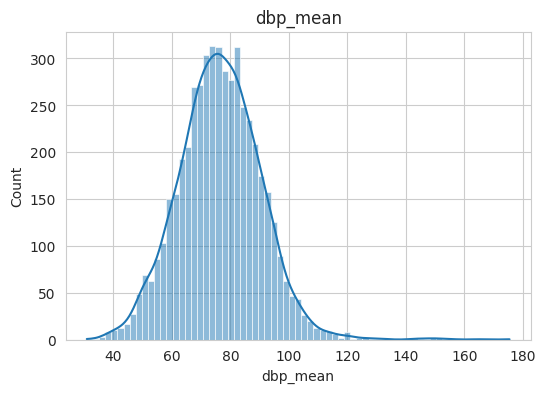

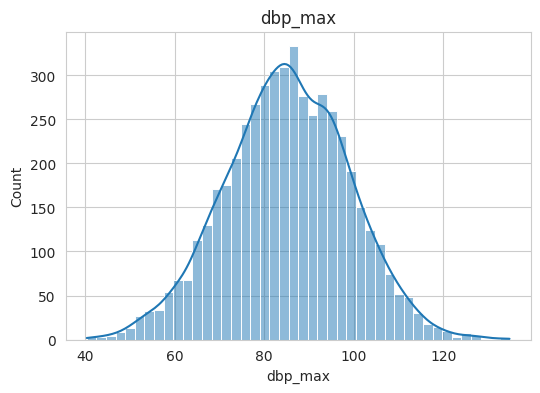

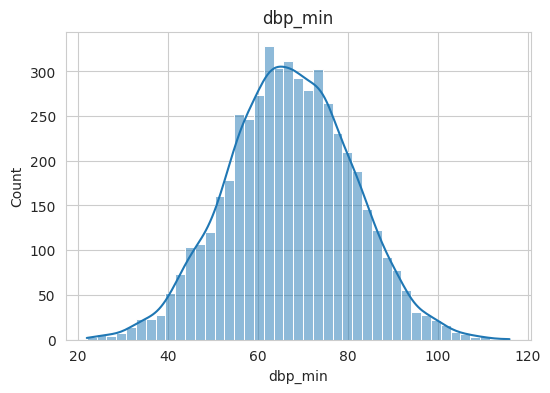

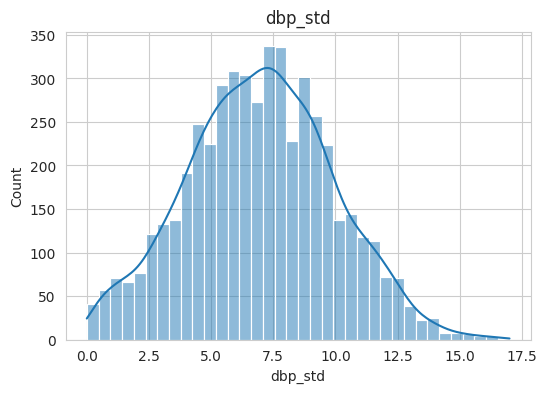

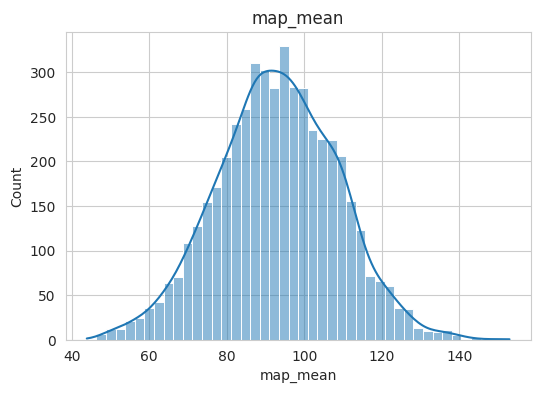

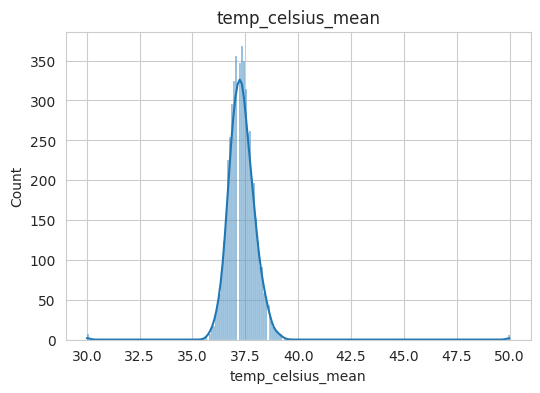

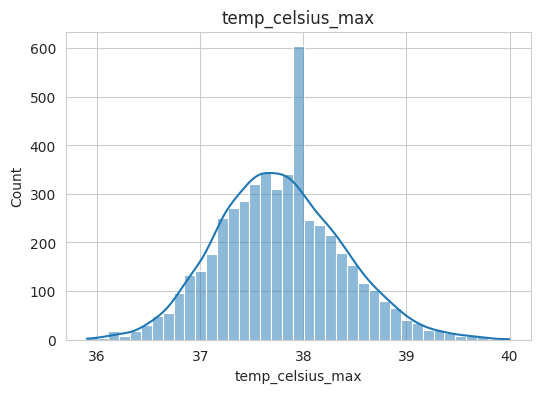

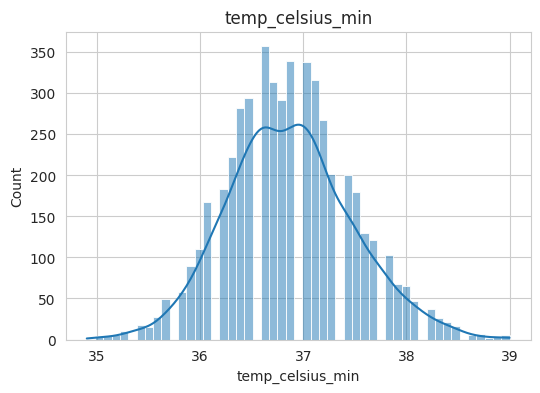

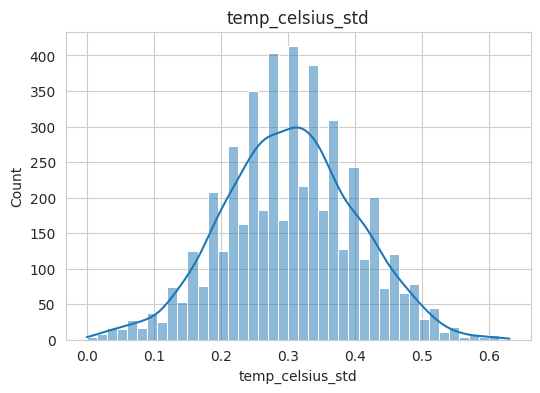

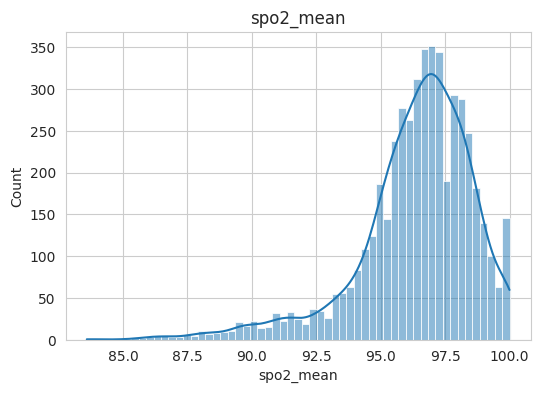

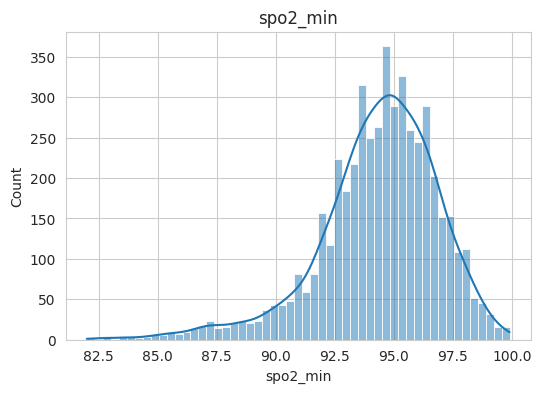

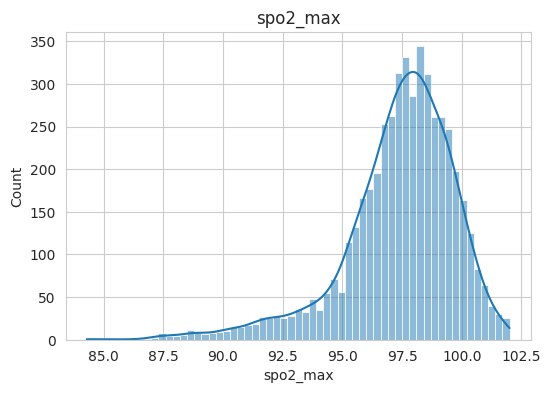

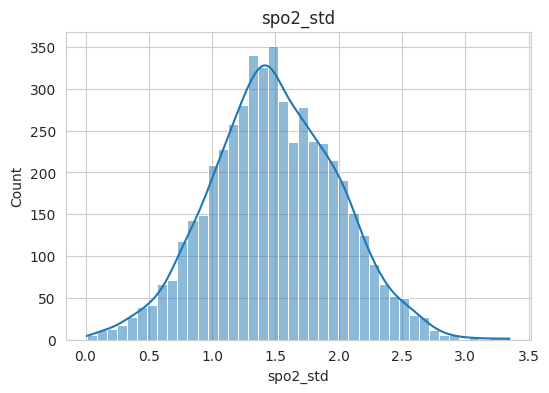

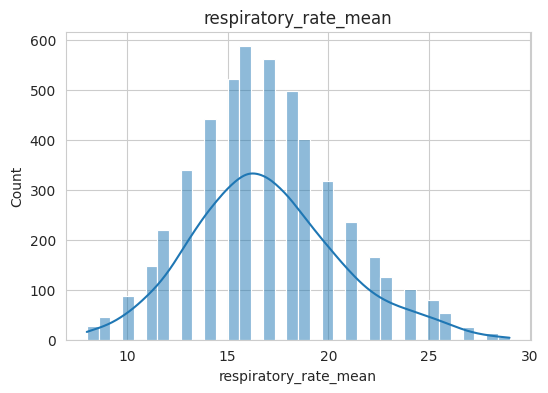

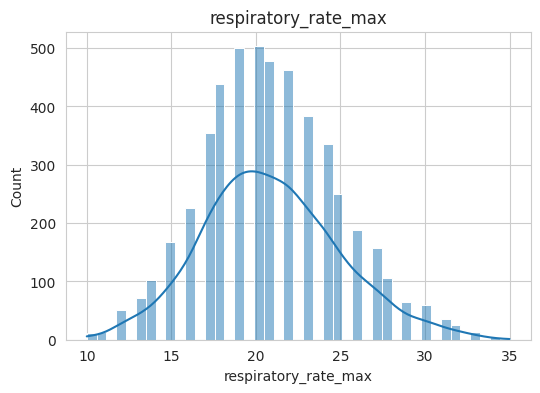

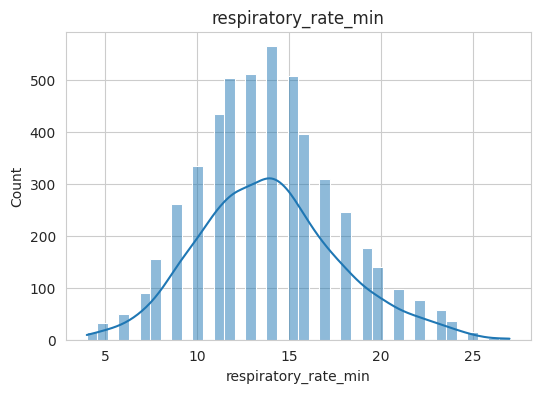

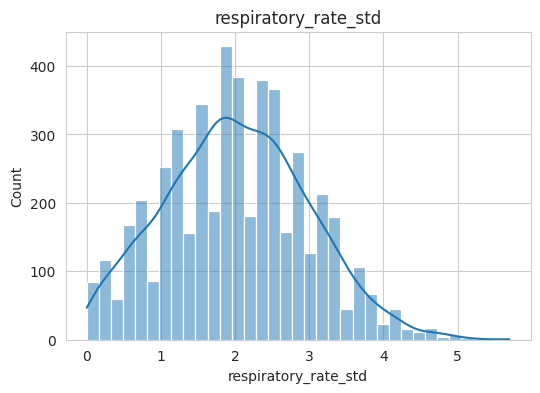

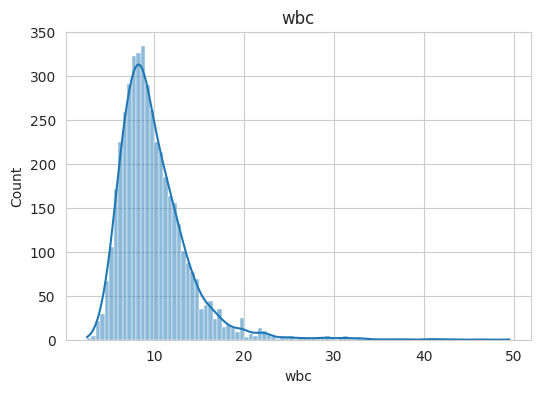

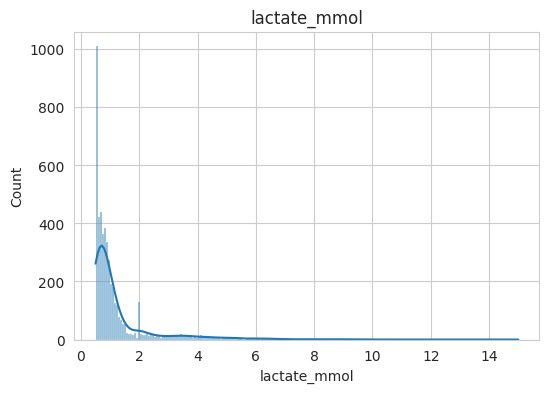

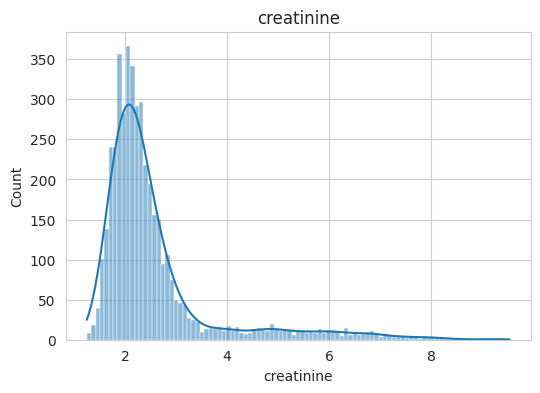

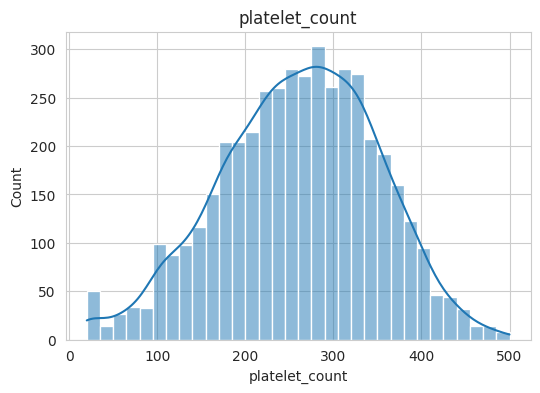

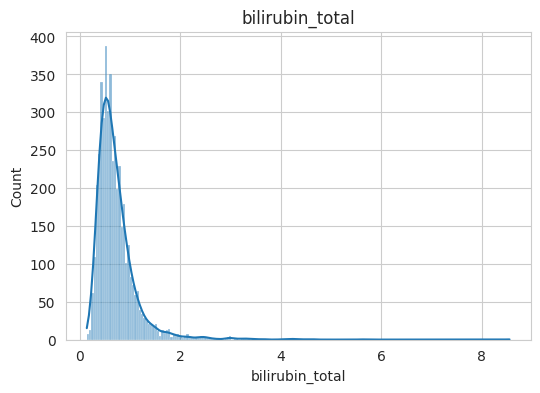

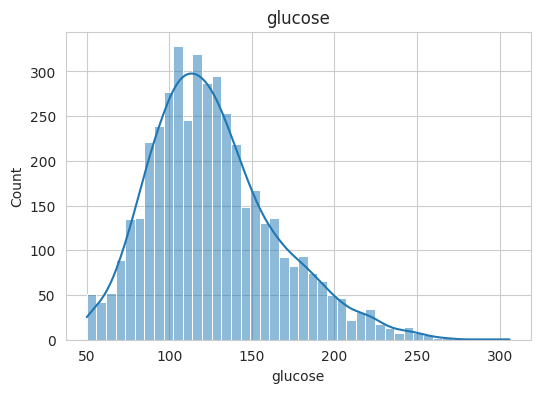

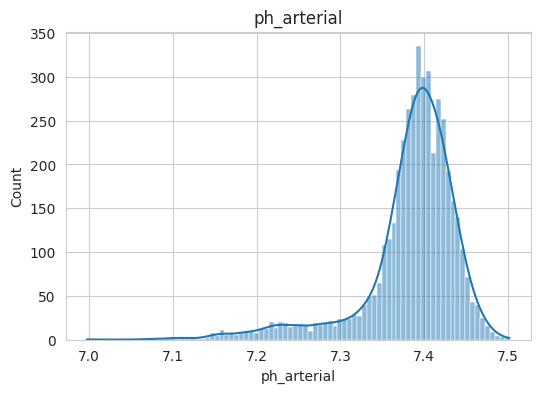

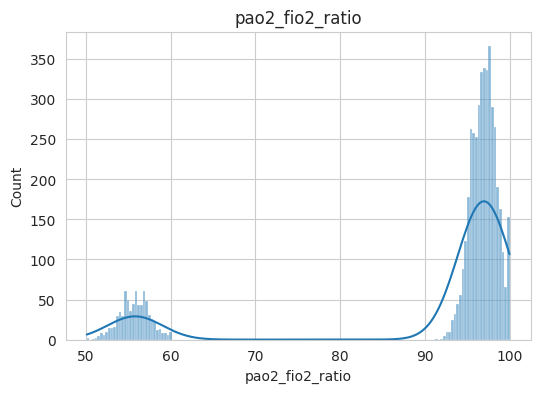

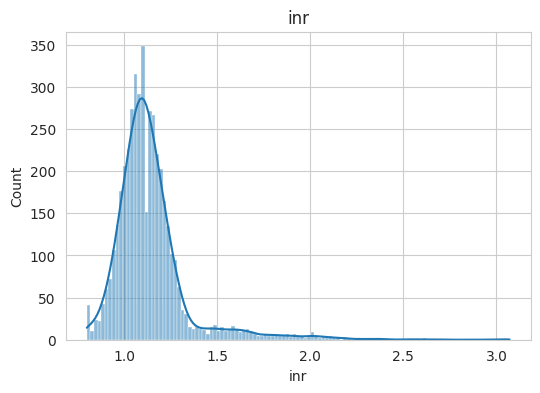

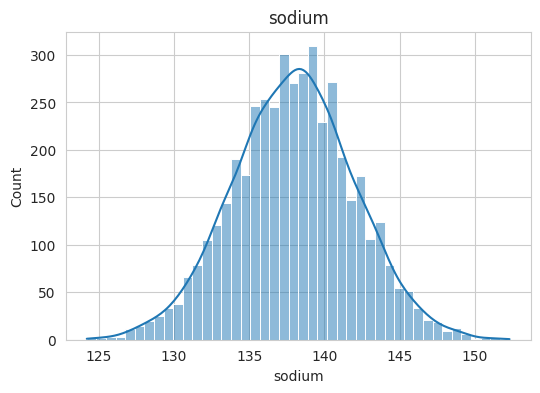

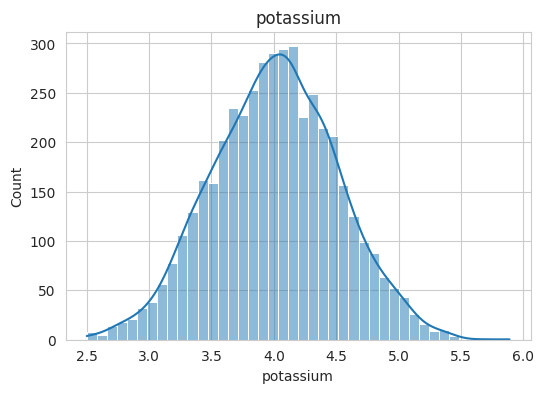

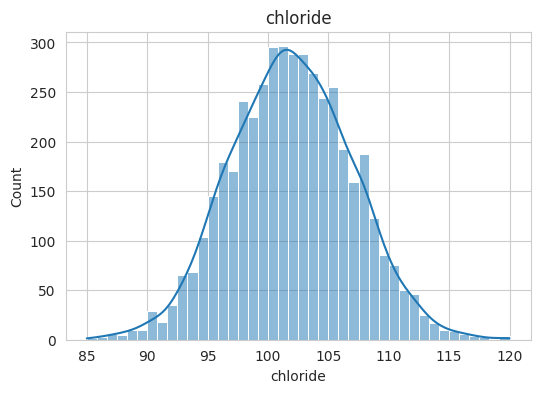

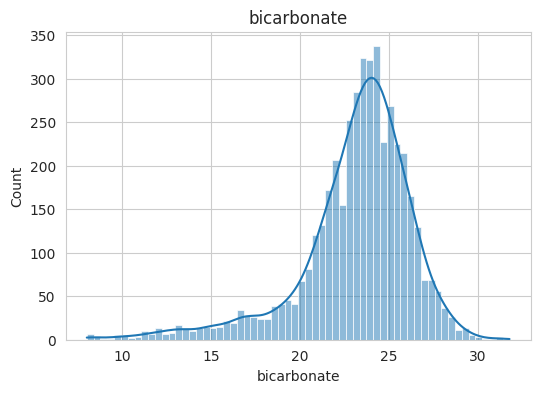

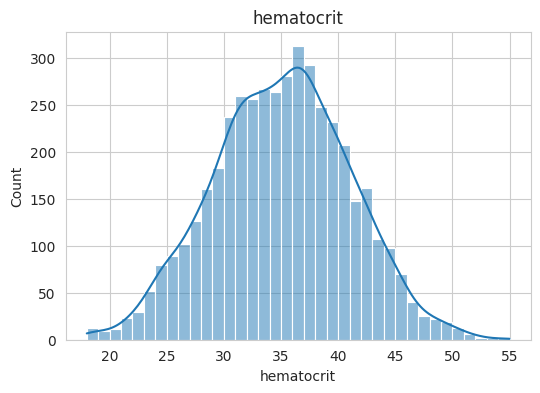

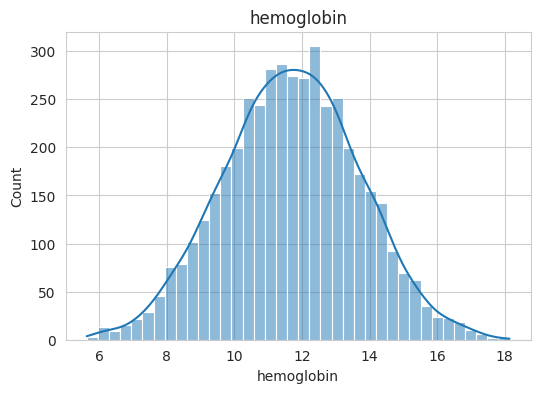

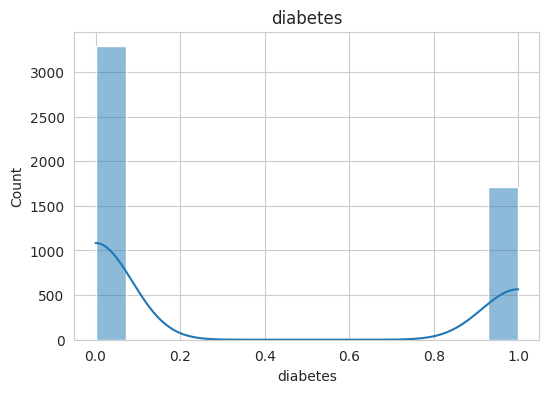

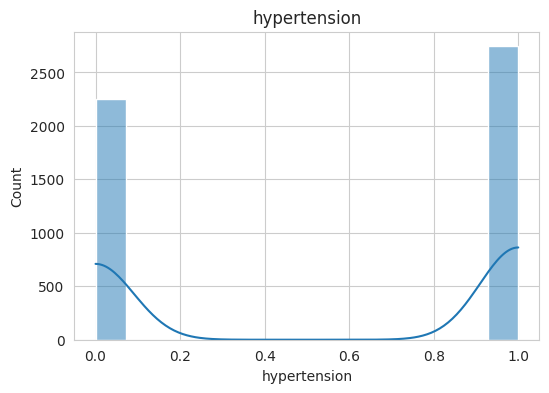

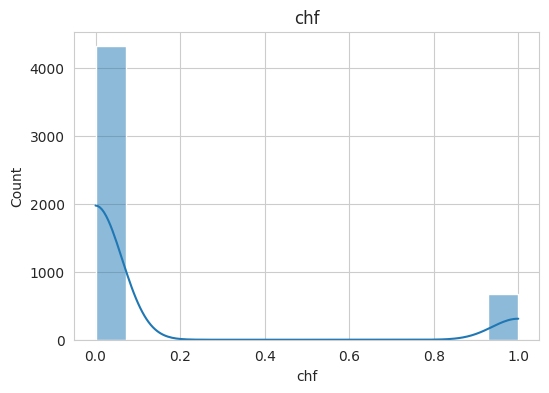

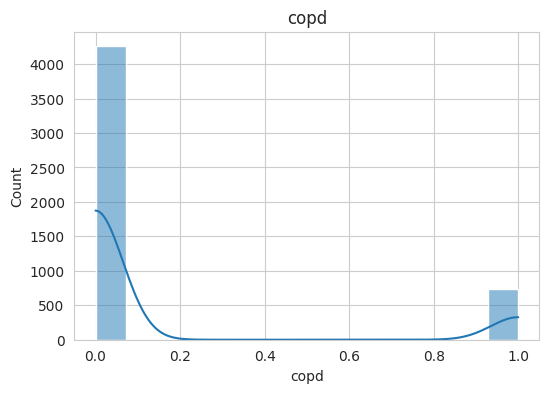

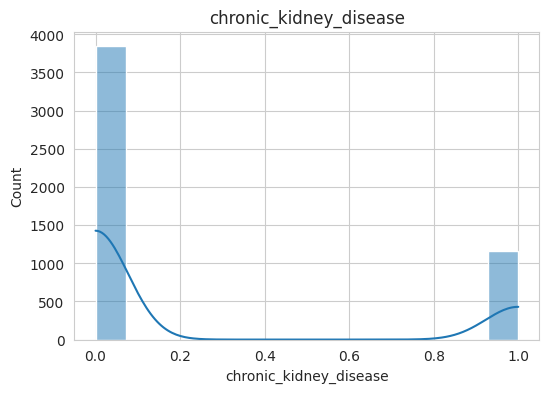

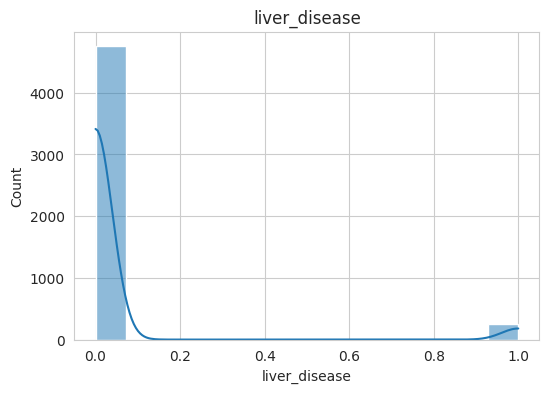

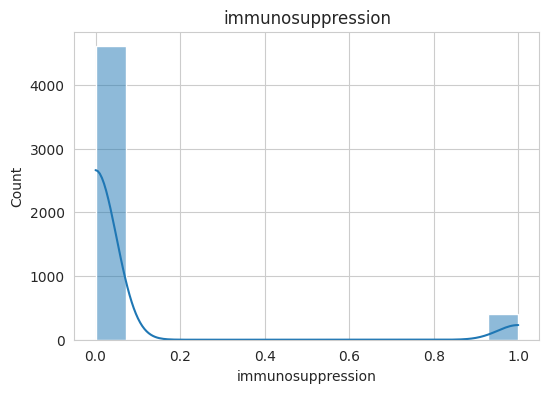

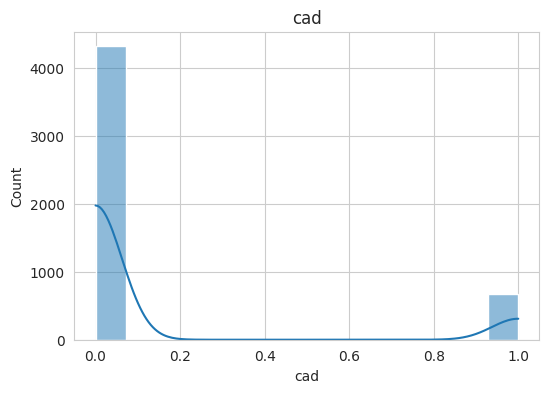

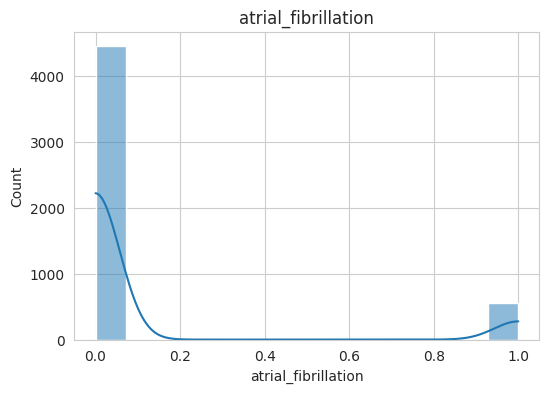

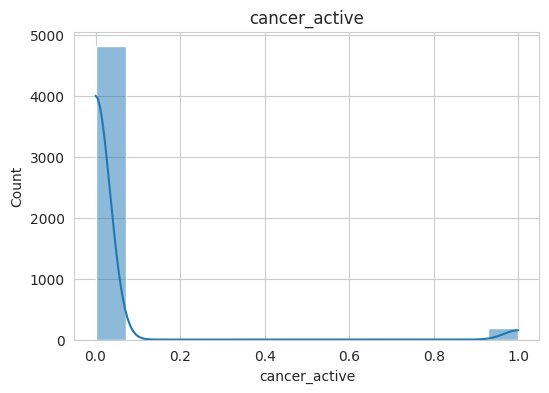

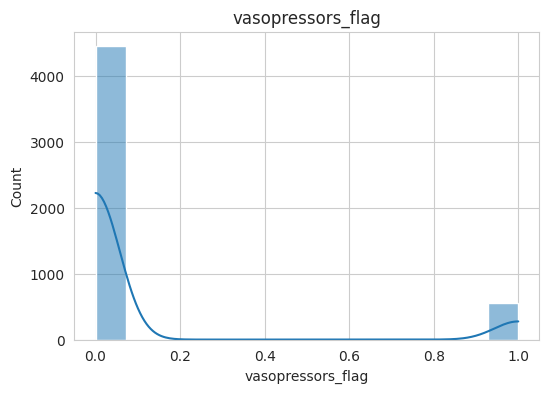

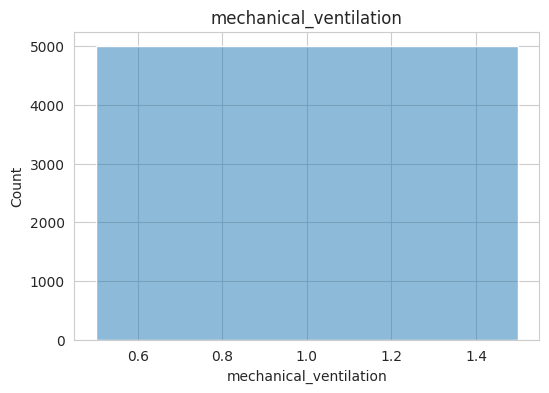

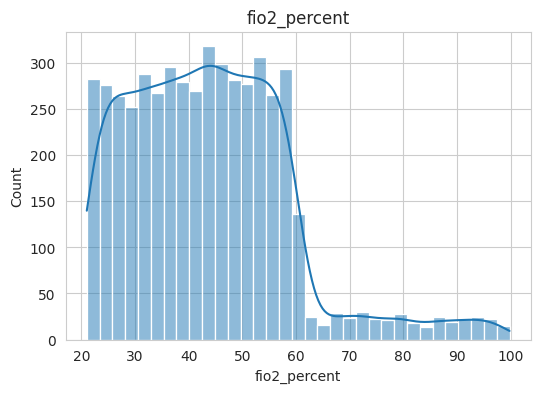

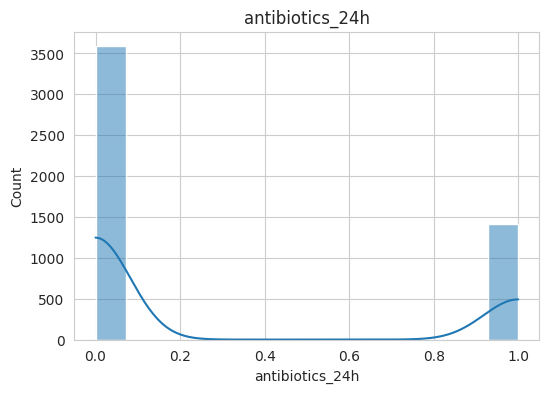

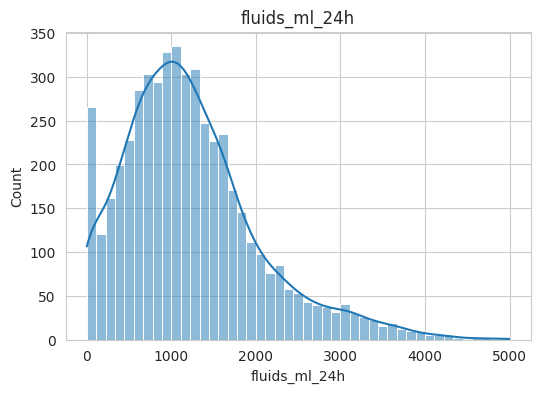

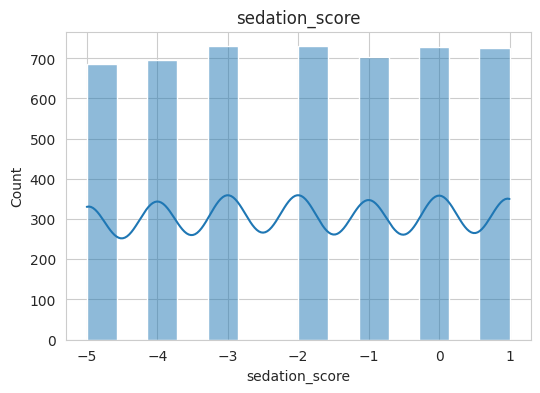

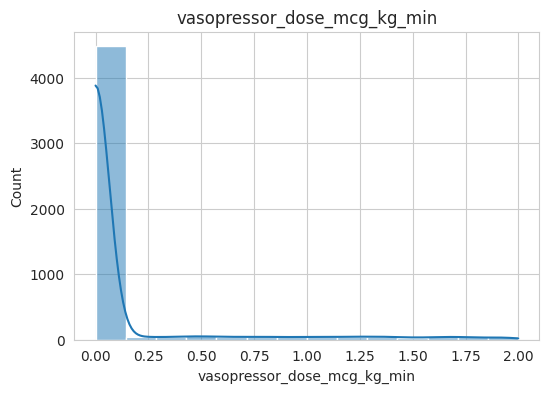

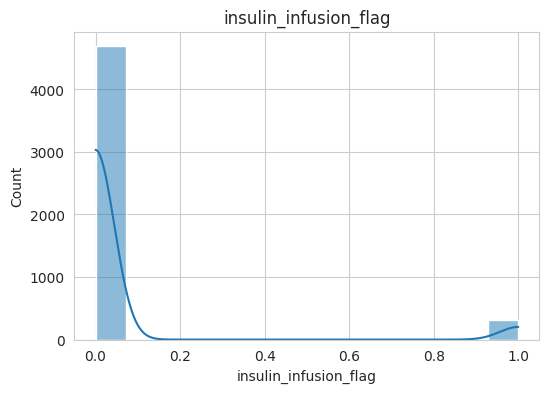

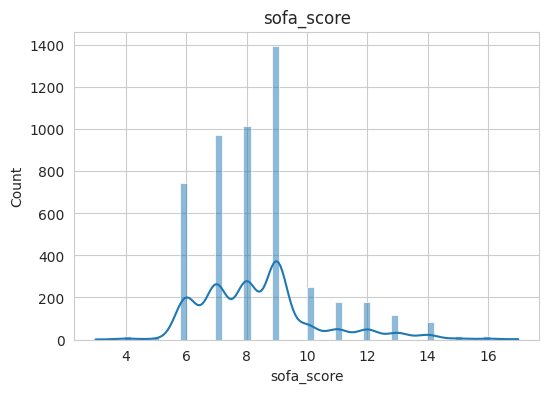

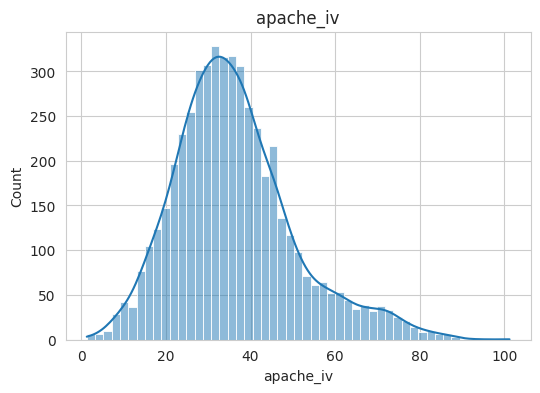

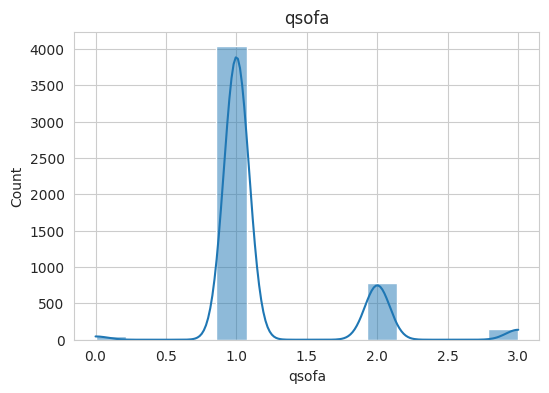

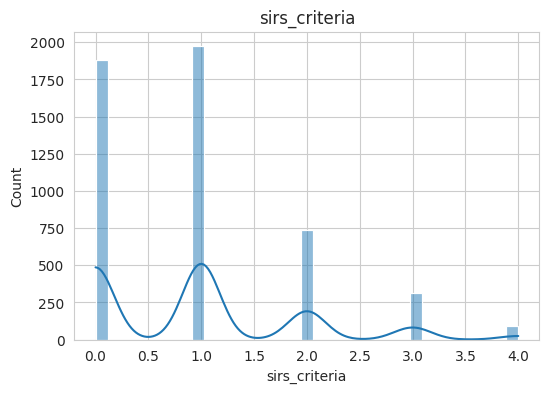

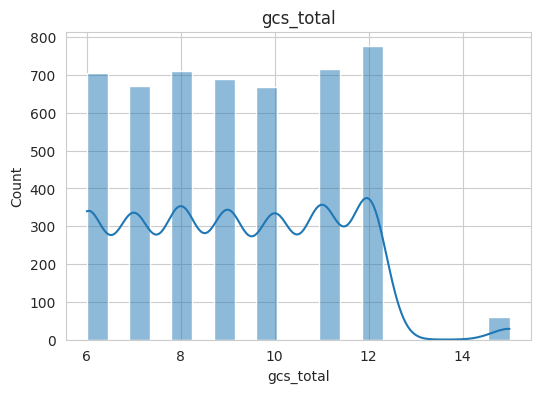

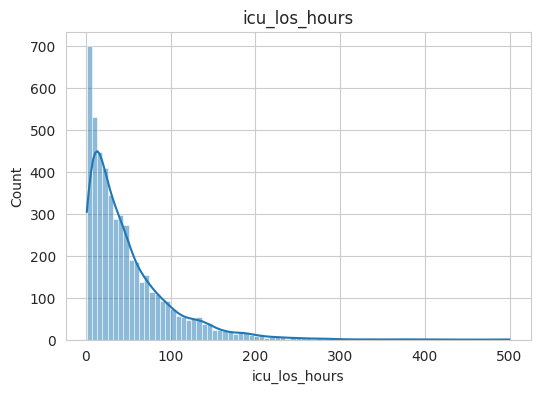

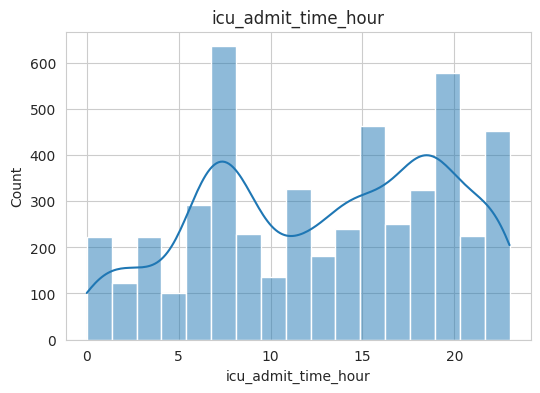

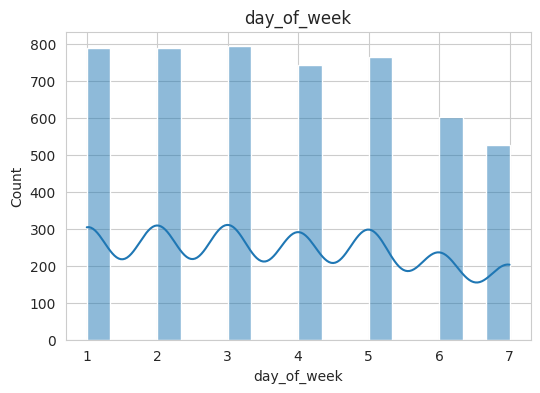

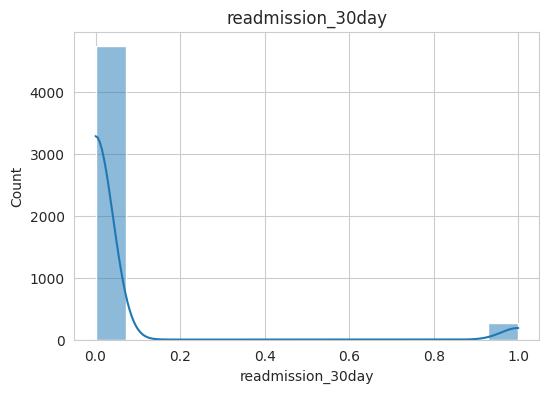

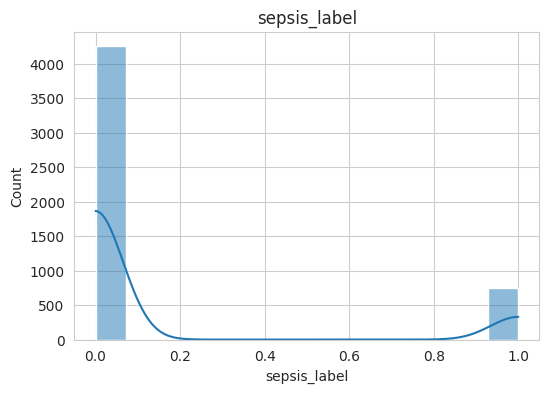

In [ ]:
# HISTOGRAM ANALYSIS
# ==========================================

for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

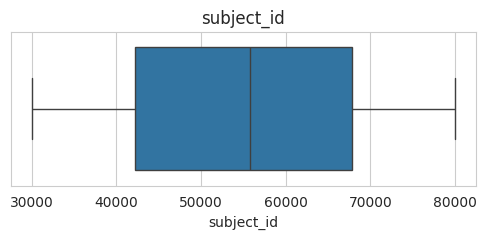

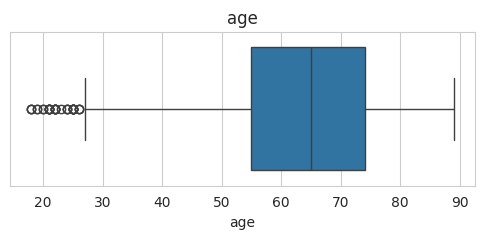

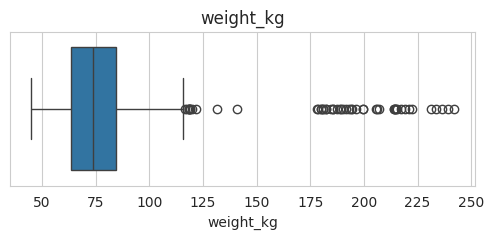

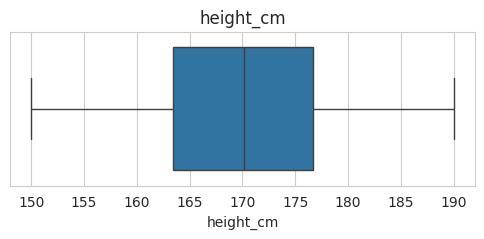

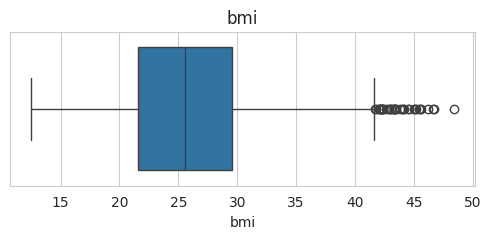

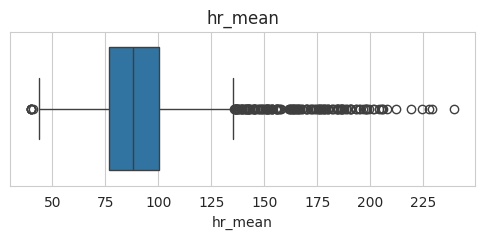

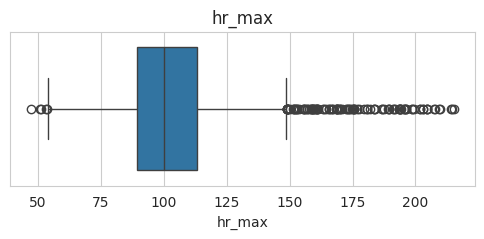

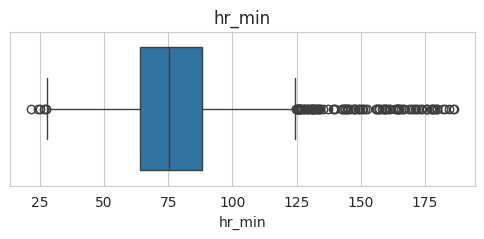

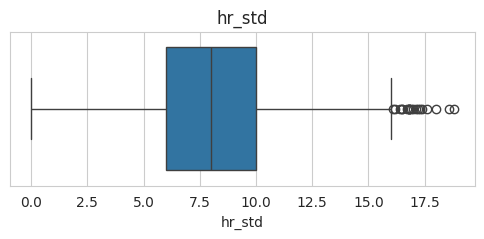

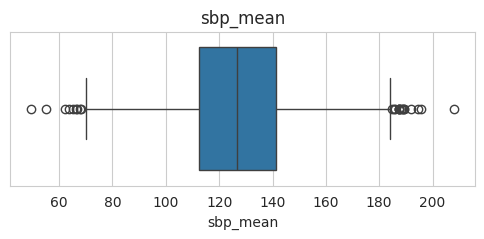

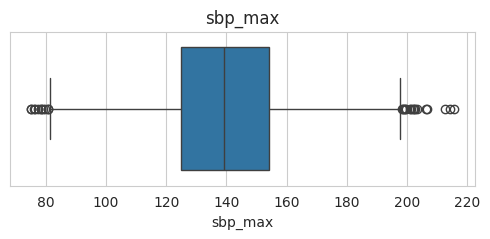

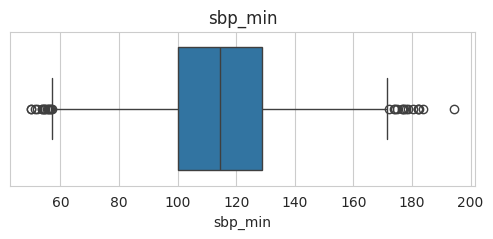

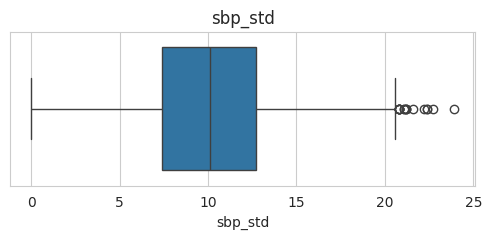

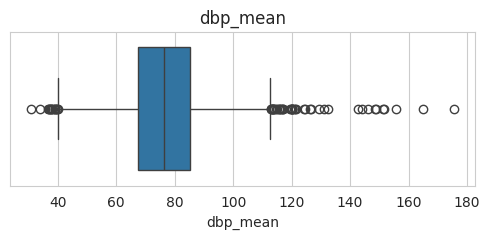

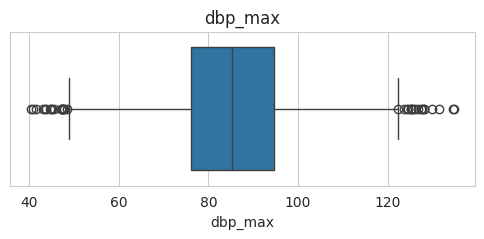

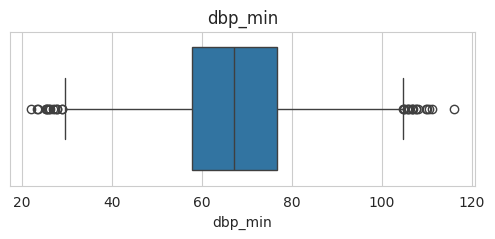

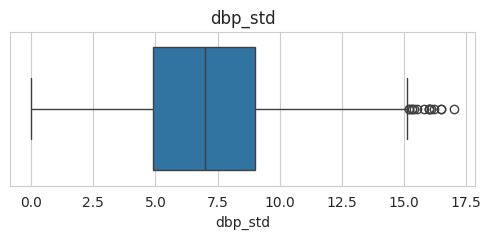

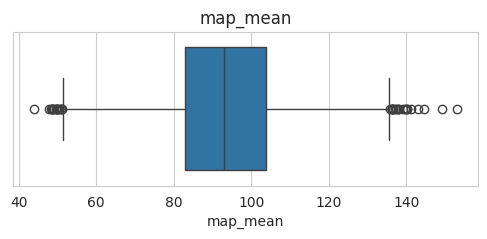

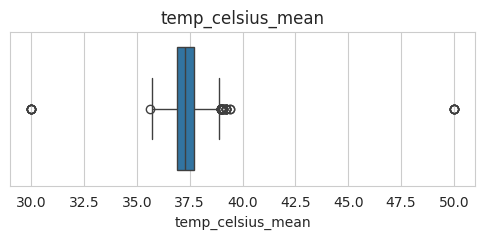

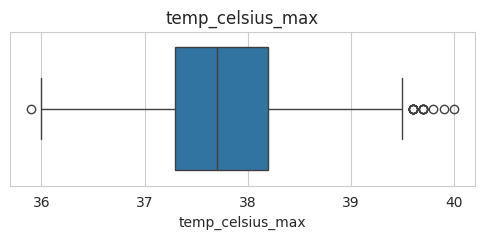

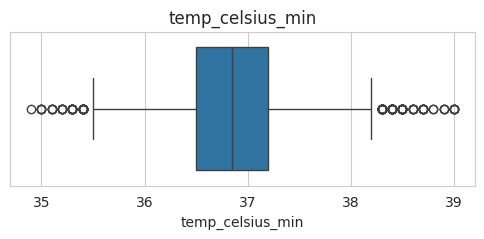

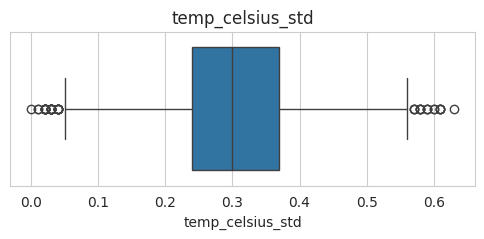

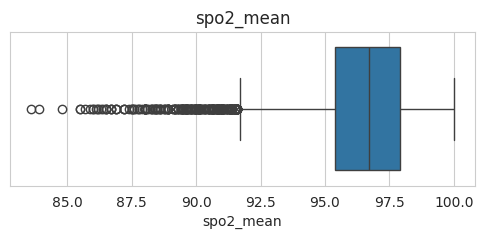

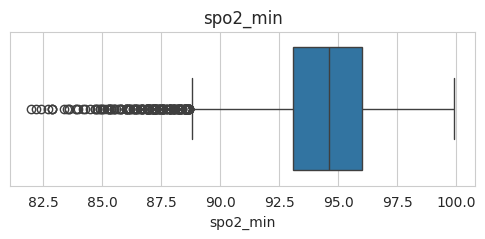

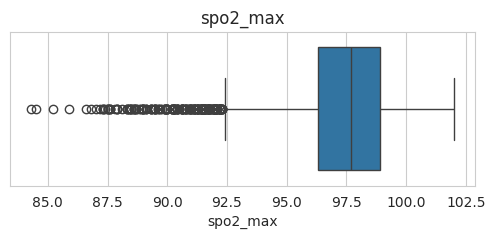

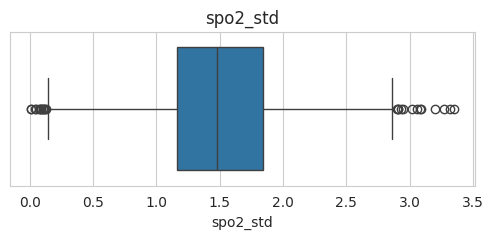

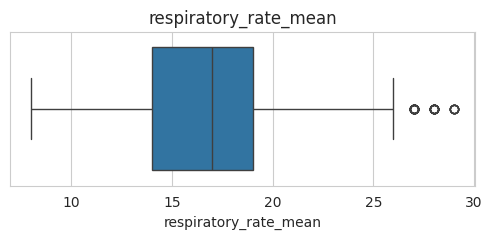

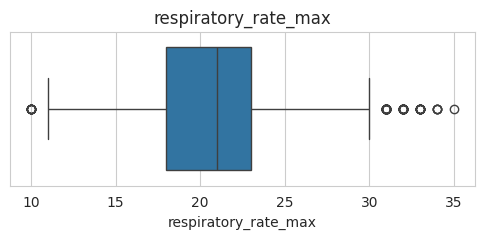

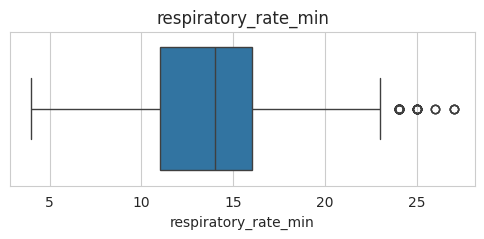

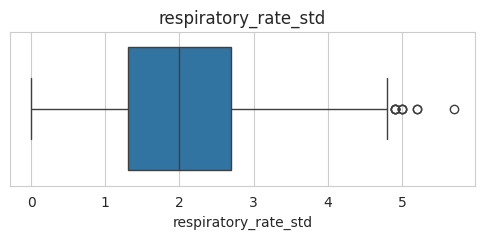

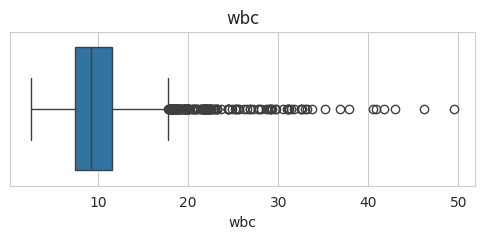

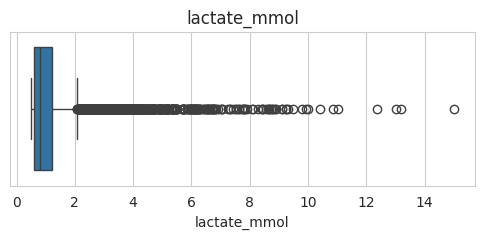

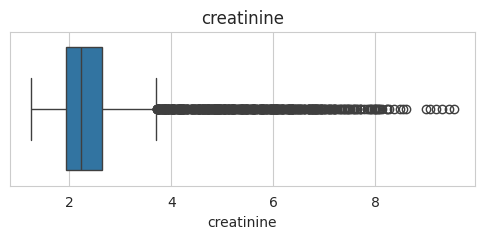

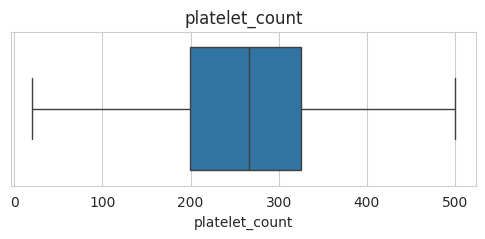

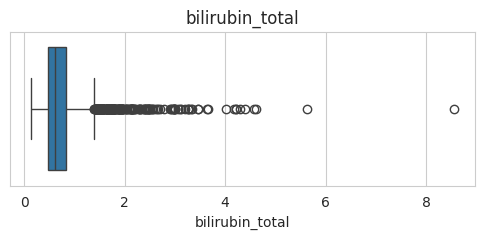

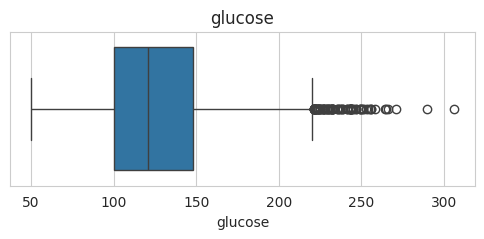

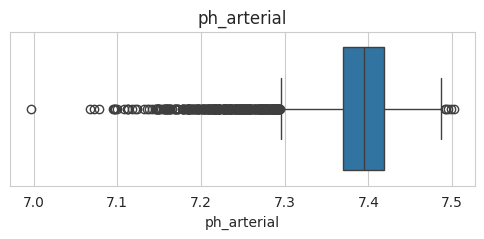

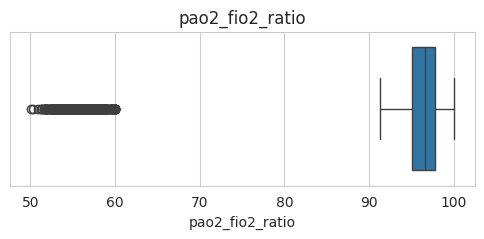

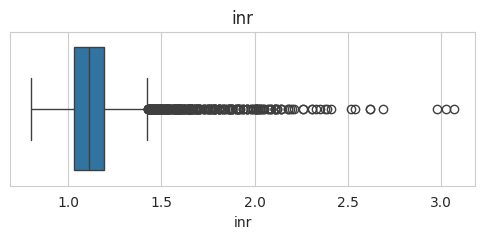

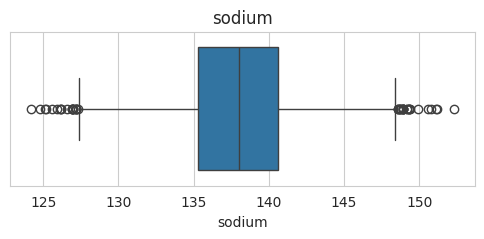

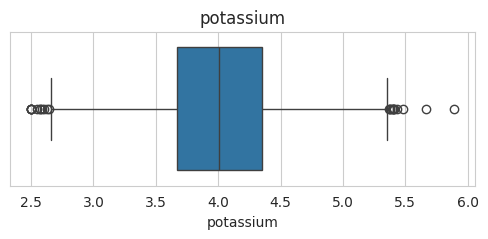

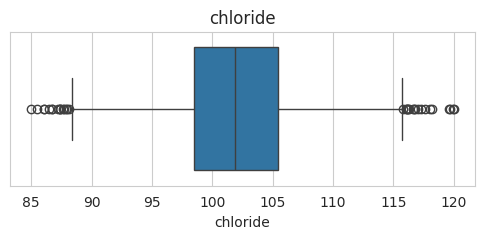

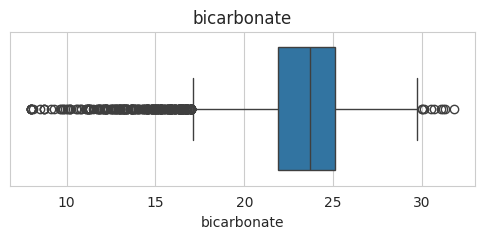

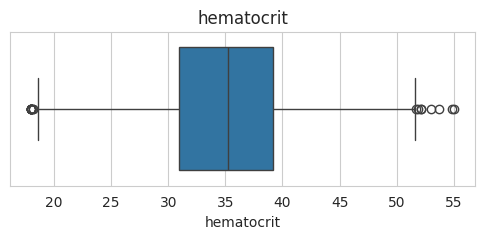

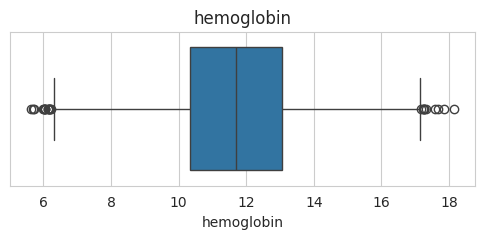

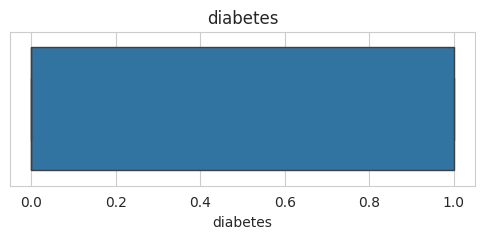

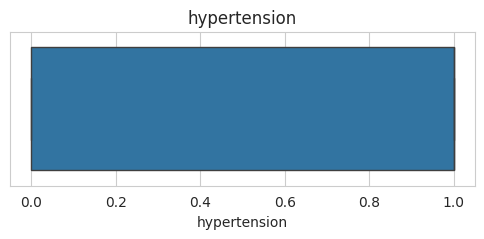

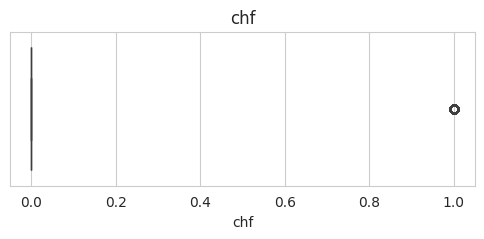

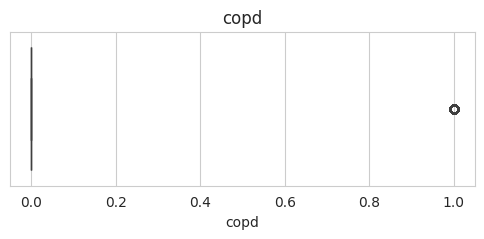

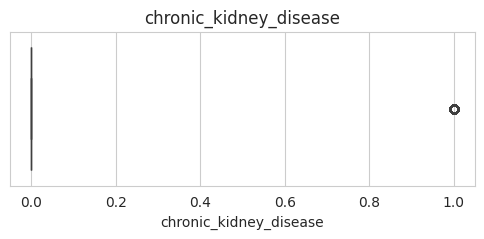

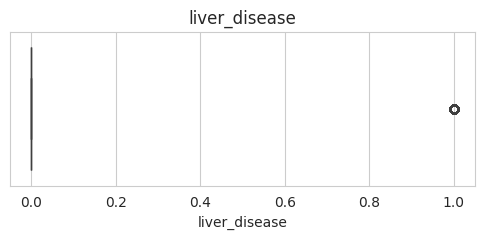

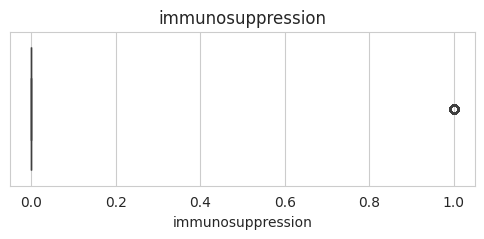

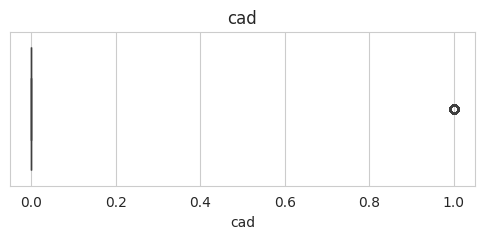

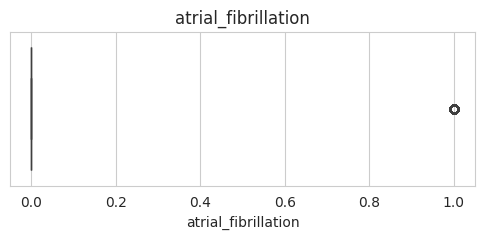

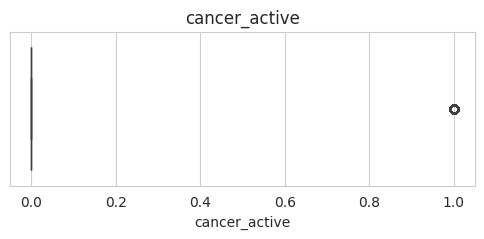

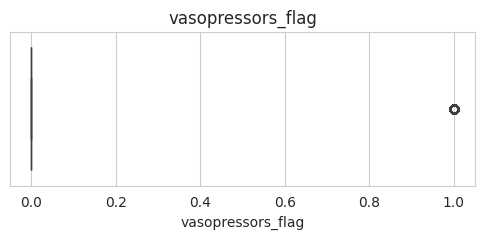

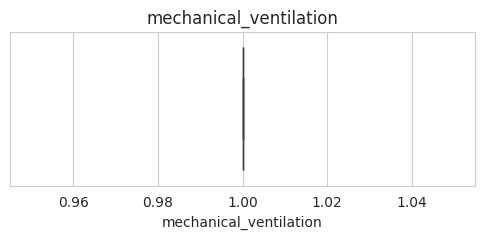

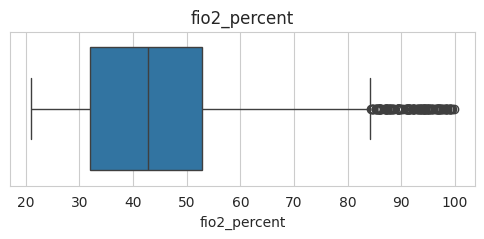

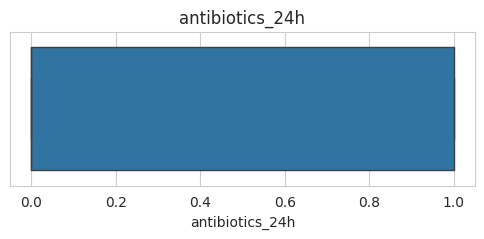

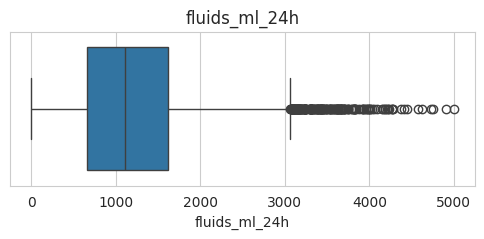

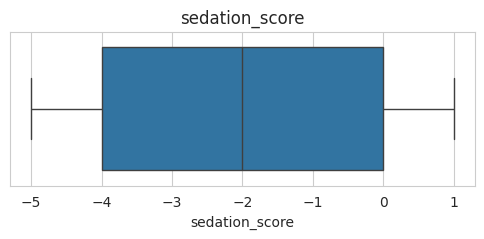

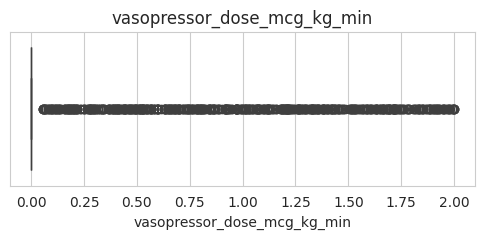

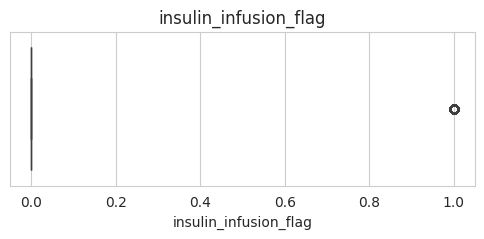

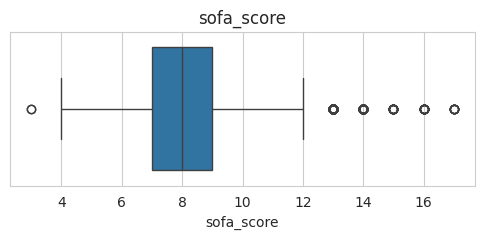

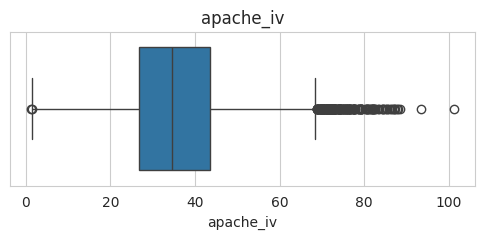

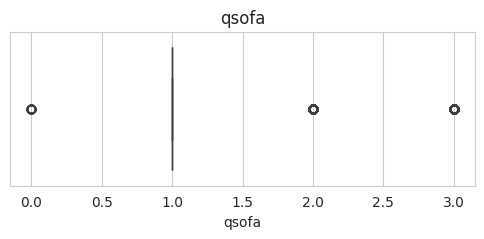

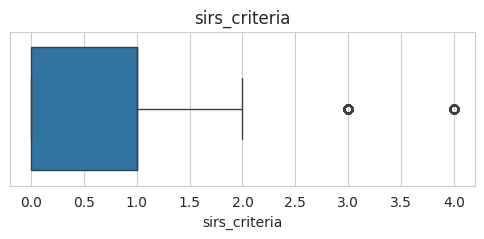

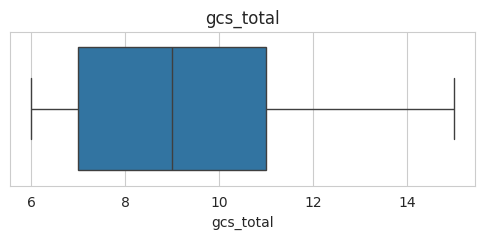

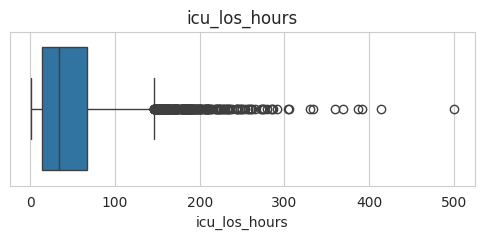

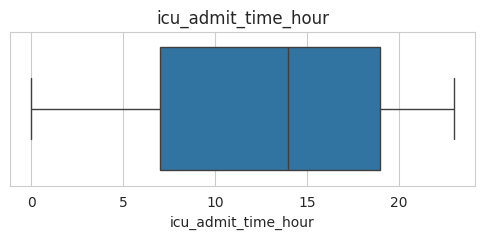

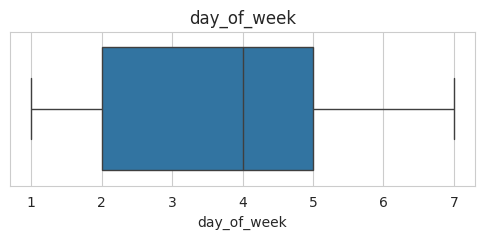

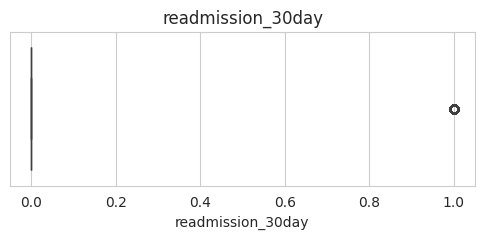

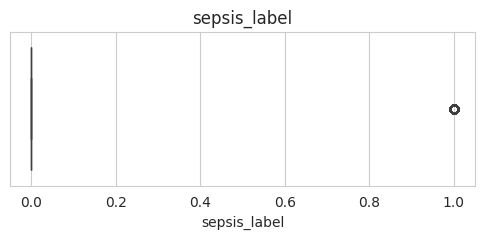

In [ ]:
# OUTLIER ANALYSIS
# ==========================================

for col in num_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

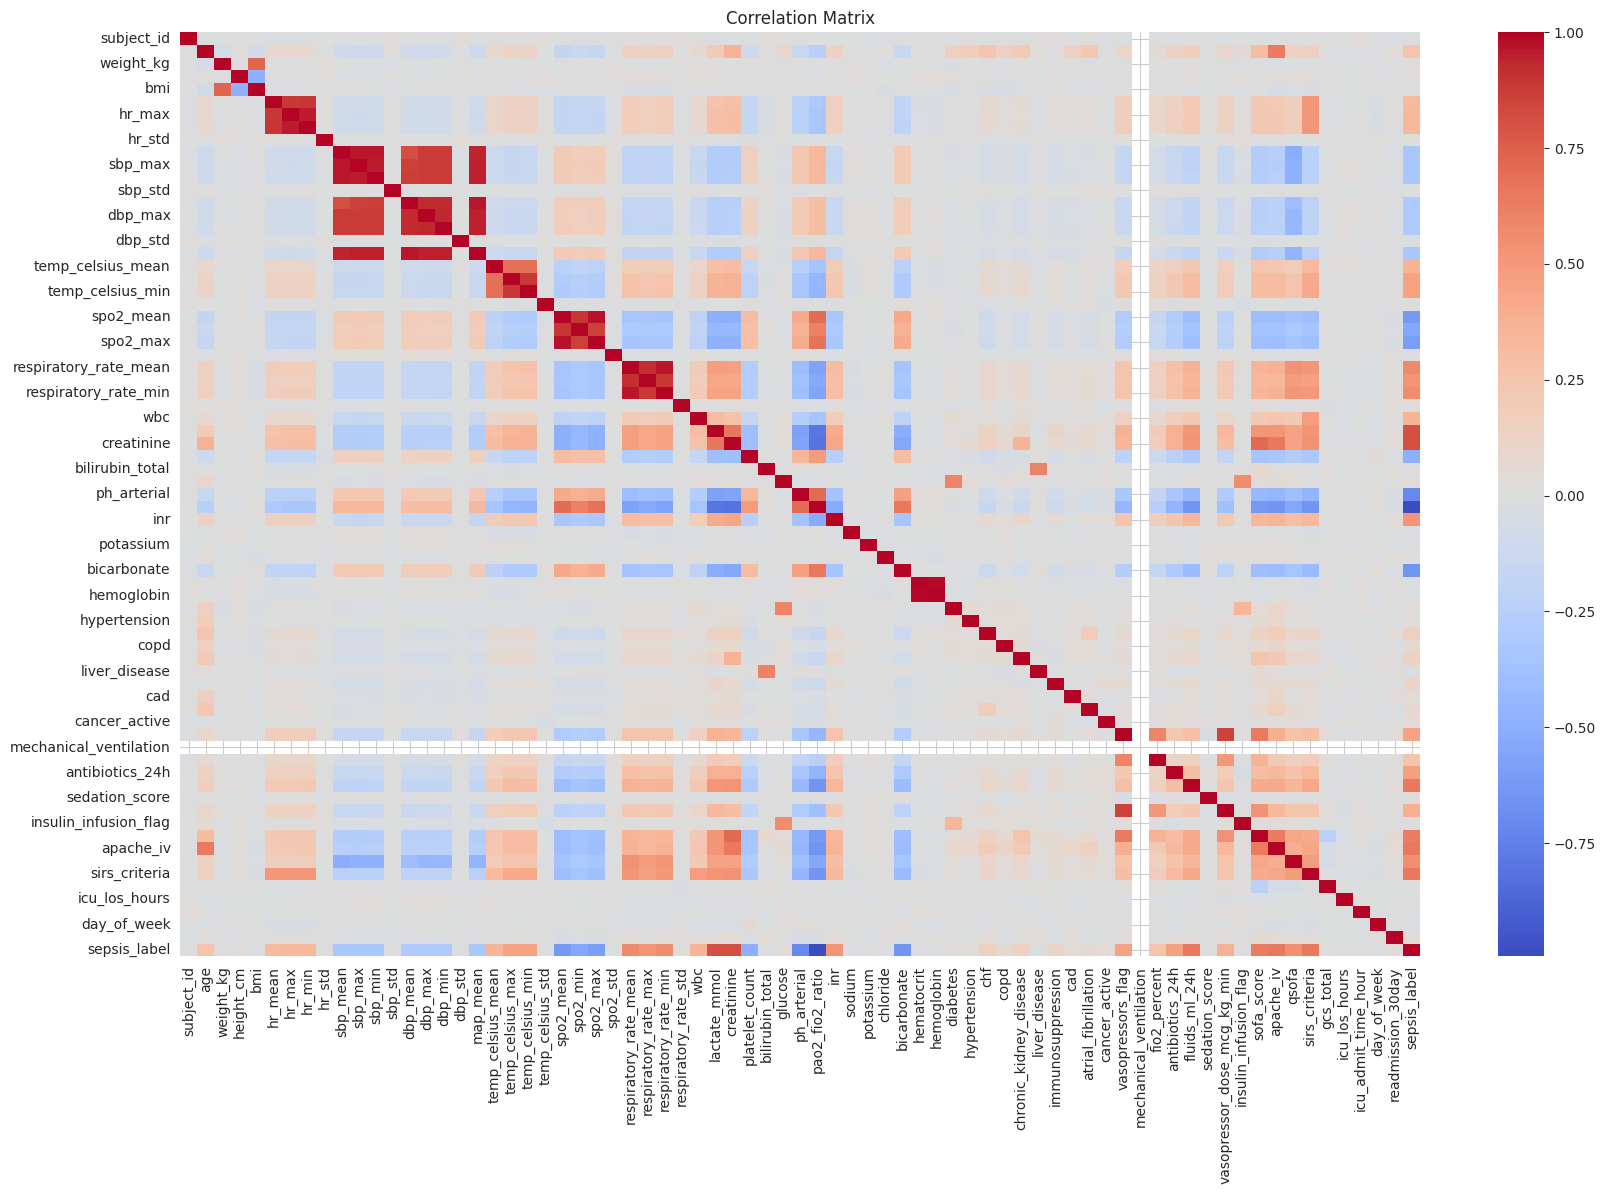

In [ ]:
# CORRELATION MATRIX
# ==========================================

corr = df[num_cols].corr()

plt.figure(figsize=(20,12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Matrix'
)

plt.show()

In [ ]:
# CORRELATION WITH TARGET
# ==========================================

corr_target = (
    corr['sepsis_label']
    .sort_values(
        ascending=False
    )
)

corr_target

,sepsis_label
sepsis_label,1.000000
creatinine,0.817425
lactate_mmol,0.807744
sirs_criteria,0.654164
apache_iv,0.652681
...,...
spo2_mean,-0.622638
bicarbonate,-0.651104
ph_arterial,-0.713661
pao2_fio2_ratio,-0.994555


In [ ]:
# FINAL EDA CONCLUSION
# ==========================================

print("""
EXPLORATORY DATA ANALYSIS (EDA) CONCLUSION

1. DATASET OVERVIEW
--------------------------------------------------
- The dataset contains 5,000 ICU patients.
- A total of 77 variables are available, including:
  * Demographic information
  * Vital signs
  * Laboratory measurements
  * Comorbidities
  * ICU interventions
  * Clinical severity scores
  * Clinical outcomes

- Target Variable:
    sepsis_label
    0 = Non-Sepsis
    1 = Sepsis

--------------------------------------------------
2. DATA QUALITY ASSESSMENT
--------------------------------------------------
- Several laboratory variables contain missing values,
  primarily ranging between 10% and 11%.

- Variables with missing values include:
    * WBC
    * Creatinine
    * Platelet Count
    * Bilirubin Total
    * INR
    * Glucose
    * Hemoglobin
    * Hematocrit

- Since the missing rate remains below 15%,
  median imputation is considered an appropriate
  preprocessing strategy.

- No severe data quality issues were identified.

--------------------------------------------------
3. TARGET DISTRIBUTION
--------------------------------------------------
- Non-Sepsis Patients : ~85%
- Sepsis Patients     : ~15%

Key Finding:
The dataset is imbalanced, with a significantly
larger proportion of non-sepsis patients.

Implication:
Future machine learning models should consider:
    * Stratified Train-Test Split
    * SMOTE Oversampling
    * Class Weight Adjustment
    * ROC-AUC and Recall as primary metrics

--------------------------------------------------
4. PATIENT CHARACTERISTICS
--------------------------------------------------
- Median patient age is approximately 65 years.
- Median ICU Length of Stay is approximately
  33.5 hours.

This indicates that the ICU population is mainly
composed of older adult patients with varying
degrees of illness severity.

--------------------------------------------------
5. POSITIVE CORRELATION WITH SEPSIS
--------------------------------------------------
The strongest positively correlated features are:

    Creatinine      : 0.817
    Lactate         : 0.808
    SIRS Criteria   : 0.654
    APACHE IV       : 0.653

Interpretation:
Patients with elevated creatinine levels,
higher lactate concentrations, and increased
severity scores are more likely to develop sepsis.

--------------------------------------------------
6. NEGATIVE CORRELATION WITH SEPSIS
--------------------------------------------------
The strongest negatively correlated features are:

    PaO2/FiO2 Ratio : -0.995
    Arterial pH     : -0.714
    Bicarbonate     : -0.651
    Mean SpO2       : -0.623

Interpretation:
Poor oxygenation status, metabolic acidosis,
and reduced oxygen saturation are strongly
associated with sepsis occurrence.

--------------------------------------------------
7. POTENTIAL DATA LEAKAGE
--------------------------------------------------
The variable:

    pao2_fio2_ratio

shows an extremely strong correlation with the
target variable (-0.995).

Recommendation:
This feature should be carefully investigated
before model development because it may introduce
data leakage and artificially inflate model
performance.

--------------------------------------------------
8. KEY FEATURE CANDIDATES
--------------------------------------------------
Based on the EDA results, the most promising
predictors of sepsis are:

    1. Creatinine
    2. Lactate
    3. APACHE IV
    4. SIRS Criteria
    5. SOFA Score
    6. WBC
    7. Respiratory Rate
    8. Vasopressor Dose
    9. Arterial pH
   10. Bicarbonate

--------------------------------------------------
9. OVERALL CONCLUSION
--------------------------------------------------
The analysis indicates that sepsis is strongly
associated with:

    * Organ dysfunction
    * Tissue hypoperfusion
    * Metabolic acidosis
    * Impaired oxygenation
    * Increased illness severity

The dataset is suitable for machine learning
development after applying appropriate
preprocessing and feature engineering techniques.

--------------------------------------------------
10. NEXT STEPS
--------------------------------------------------
1. Missing Value Imputation
2. Feature Engineering
3. Categorical Encoding
4. Train-Test Split
5. SMOTE Oversampling
6. Feature Scaling
7. Logistic Regression
8. Random Forest
9. XGBoost
10. Model Evaluation
11. Feature Importance Analysis

The dataset is considered ready for the machine
learning phase.
""")


EXPLORATORY DATA ANALYSIS (EDA) CONCLUSION

1. DATASET OVERVIEW
--------------------------------------------------
- The dataset contains 5,000 ICU patients.
- A total of 77 variables are available, including:
  * Demographic information
  * Vital signs
  * Laboratory measurements
  * Comorbidities
  * ICU interventions
  * Clinical severity scores
  * Clinical outcomes

- Target Variable:
    sepsis_label
    0 = Non-Sepsis
    1 = Sepsis

--------------------------------------------------
2. DATA QUALITY ASSESSMENT
--------------------------------------------------
- Several laboratory variables contain missing values,
  primarily ranging between 10% and 11%.

- Variables with missing values include:
    * WBC
    * Creatinine
    * Platelet Count
    * Bilirubin Total
    * INR
    * Glucose
    * Hemoglobin
    * Hematocrit

- Since the missing rate remains below 15%,
  median imputation is considered an appropriate
  preprocessing strategy.

- No severe data quality issues were i

In [ ]:
# FEATURE ENGINEERING
# ==========================================
# Prepare the dataset for machine learning by
# handling missing values, encoding categorical
# variables, addressing class imbalance, and
# scaling numerical features when necessary.

In [ ]:
# FEATURE ENGINEERING 1. CREATE WORKING COPY
# ==========================================

df_ml = df.copy()

In [ ]:
# FEATURE ENGINEERING 2. REMOVE IDENTIFIER
# ==========================================

df_ml.drop(
    columns=['subject_id'],
    inplace=True
)

print("Remaining Features:", df_ml.shape[1])

Remaining Features: 76


In [ ]:
# FEATURE ENGINEERING 3. HANDLE MISSING VALUES
# ==========================================

num_cols = df_ml.select_dtypes(
    include=['int64','float64']
).columns

for col in num_cols:

    df_ml[col] = df_ml[col].fillna(
        df_ml[col].median()
    )

print(
    "Remaining Missing Values:",
    df_ml.isnull().sum().sum()
)

Remaining Missing Values: 0


In [ ]:
# FEATURE ENGINEERING 4. VERIFY MISSING VALUES
# ==========================================

df_ml.isnull().sum().sort_values(
    ascending=False
).head(10)

,0
age,0
gender,0
weight_kg,0
height_cm,0
bmi,0
ethnicity,0
insurance,0
hr_mean,0
hr_max,0
hr_min,0


In [ ]:
# FEATURE ENGINEERING 5. DETECT POTENTIAL
# DATA LEAKAGE
# ==========================================

corr = df_ml.corr(
    numeric_only=True
)

corr['sepsis_label'].sort_values()

,sepsis_label
pao2_fio2_ratio,-0.994555
ph_arterial,-0.661306
spo2_mean,-0.622638
spo2_max,-0.601643
bicarbonate,-0.596730
...,...
sirs_criteria,0.654164
creatinine,0.749847
lactate_mmol,0.807744
sepsis_label,1.000000


In [ ]:
# FEATURE ENGINEERING 6. REMOVE LEAKAGE
# FEATURE
# ==========================================

df_ml.drop(
    columns=['pao2_fio2_ratio'],
    inplace=True
)

print(df_ml.shape)

(5000, 75)


In [ ]:
# FEATURE ENGINEERING 7. IDENTIFY
# CATEGORICAL FEATURES
# ==========================================

cat_cols = df_ml.select_dtypes(
    include='object'
).columns

cat_cols

Index(['gender', 'ethnicity', 'insurance', 'hospital_admit_source'], dtype='object')

In [ ]:
# FEATURE ENGINEERING 8. ONE HOT ENCODING
# ==========================================

df_ml = pd.get_dummies(
    df_ml,
    columns=cat_cols,
    drop_first=True
)

print(df_ml.shape)

(5000, 83)


In [ ]:
# FEATURE ENGINEERING 9. DEFINE FEATURES
# AND TARGET
# ==========================================

X = df_ml.drop(
    columns=['sepsis_label']
)

y = df_ml['sepsis_label']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (5000, 82)
y Shape: (5000,)


In [ ]:
# FEATURE ENGINEERING 10. TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (4000, 82)
Testing Set  : (1000, 82)


In [ ]:
# FEATURE ENGINEERING 11. CHECK CLASS
# DISTRIBUTION
# ==========================================

print(y_train.value_counts())

print(
    round(
        y_train.value_counts(normalize=True)*100,
        2
    )
)

sepsis_label
0    3400
1     600
Name: count, dtype: int64
sepsis_label
0    85.0
1    15.0
Name: proportion, dtype: float64


In [ ]:
# FEATURE ENGINEERING 12. APPLY SMOTE
# ==========================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(
    pd.Series(y_train_smote).value_counts()
)

sepsis_label
0    3400
1    3400
Name: count, dtype: int64


In [ ]:
# FEATURE ENGINEERING 13. FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaling Complete")

Scaling Complete


In [ ]:
# FEATURE ENGINEERING 14. FINAL DATASET
# INSPECTION
# ==========================================

print("Training Features :", X_train_scaled.shape)
print("Testing Features  :", X_test_scaled.shape)

print(
    "Training Labels :",
    len(y_train_smote)
)

print(
    "Testing Labels :",
    len(y_test)
)

Training Features : (6800, 82)
Testing Features  : (1000, 82)
Training Labels : 6800
Testing Labels : 1000


In [ ]:
# FEATURE ENGINEERING CONCLUSION
# ==========================================
# Summary:
#
# ✓ Missing values handled using median
#   imputation.
#
# ✓ Potential leakage feature removed.
#
# ✓ Categorical variables encoded using
#   One-Hot Encoding.
#
# ✓ Dataset split into train and test sets.
#
# ✓ Class imbalance addressed using SMOTE.
#
# ✓ Features standardized using
#   StandardScaler.
#
# The dataset is now ready for:
#
# 1. Logistic Regression
# 2. Random Forest
# 3. XGBoost
# 4. Model Comparison
# 5. Feature Importance Analysis

In [ ]:
# MODEL 1. LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train_smote
)

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


In [ ]:
# Generate predictions

y_pred_lr = lr.predict(
    X_test_scaled
)

y_prob_lr = lr.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       850
           1       1.00      0.99      1.00       150

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

In [ ]:
# MODEL 2. RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest Training Complete")

Random Forest Training Complete


In [ ]:
y_pred_rf = rf.predict(
    X_test
)

y_prob_rf = rf.predict_proba(
    X_test
)[:,1]

In [ ]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       850
           1       1.00      1.00      1.00       150

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
# MODEL 3. XGBOOST
# ==========================================

from xgboost import XGBClassifier

xgb = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric='logloss'
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost Training Complete")

XGBoost Training Complete


In [ ]:
y_pred_xgb = xgb.predict(
    X_test
)

y_prob_xgb = xgb.predict_proba(
    X_test
)[:,1]

In [ ]:
print(classification_report(
    y_test,
    y_pred_xgb
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       850
           1       0.98      1.00      0.99       150

    accuracy                           1.00      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
corr_target = (
    df_ml.corr(numeric_only=True)
    ['sepsis_label']
    .sort_values(
        key=abs,
        ascending=False
    )
)

corr_target.head(20)

,sepsis_label
sepsis_label,1.000000
lactate_mmol,0.807744
creatinine,0.749847
ph_arterial,-0.661306
sirs_criteria,0.654164
apache_iv,0.652681
fluids_ml_24h,0.649639
sofa_score,0.626129
spo2_mean,-0.622638
spo2_max,-0.601643


In [ ]:
drop_cols = [

    'sofa_score',
    'qsofa',
    'apache_iv',
    'sirs_criteria'

]

X2 = df_ml.drop(
    columns=drop_cols + ['sepsis_label']
)

y2 = df_ml['sepsis_label']

In [ ]:
# LEAKAGE VALIDATION 1. CREATE REDUCED DATASET
# ==========================================
# Objective:
# Remove clinical severity scores that may
# contain information highly related to
# sepsis diagnosis.
#
# Removed Features:
# - SOFA Score
# - qSOFA
# - APACHE IV
# - SIRS Criteria

df_reduced = df_ml.copy()

drop_cols = [
    'sofa_score',
    'qsofa',
    'apache_iv',
    'sirs_criteria',

    # leakage candidates
    'pao2_fio2_ratio',

    # treatment-related
    'antibiotics_24h',
    'mechanical_ventilation',
    'vasopressors_flag',
    'vasopressor_dose_mcg_kg_min',

    # future information
    'icu_los_hours',
    'readmission_30day'
]

existing_cols = [c for c in drop_cols if c in df_reduced.columns]

df_reduced = df_reduced.drop(
    columns=existing_cols
)

print(df_reduced.shape)

(5000, 73)


In [ ]:
# LEAKAGE VALIDATION 2. DEFINE FEATURES
# AND TARGET
# ==========================================

X_reduced = df_reduced.drop(
    columns=['sepsis_label']
)

y_reduced = df_reduced['sepsis_label']

print(X_reduced.shape)
print(y_reduced.shape)

(5000, 72)
(5000,)


In [ ]:
# LEAKAGE VALIDATION 3. TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

    X_reduced,

    y_reduced,

    test_size=0.20,

    random_state=42,

    stratify=y_reduced
)

print(X_train_r.shape)
print(X_test_r.shape)

(4000, 72)
(1000, 72)


In [ ]:
# LEAKAGE VALIDATION 4. APPLY SMOTE
# ==========================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_r_smote, y_train_r_smote = smote.fit_resample(

    X_train_r,

    y_train_r
)

print(pd.Series(
    y_train_r_smote
).value_counts())

sepsis_label
0    3400
1    3400
Name: count, dtype: int64


In [ ]:
# LEAKAGE VALIDATION 5. SCALE FEATURES
# ==========================================
# Logistic Regression requires scaling.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_r_scaled = scaler.fit_transform(
    X_train_r_smote
)

X_test_r_scaled = scaler.transform(
    X_test_r
)

In [ ]:
# VALIDATION MODEL 1. LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression

lr_reduced = LogisticRegression(

    max_iter=1000,

    random_state=42
)

lr_reduced.fit(

    X_train_r_scaled,

    y_train_r_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# VALIDATION MODEL 1. PREDICTION
# ==========================================

y_pred_lr_r = lr_reduced.predict(
    X_test_r_scaled
)

y_prob_lr_r = lr_reduced.predict_proba(
    X_test_r_scaled
)[:,1]

In [ ]:
# VALIDATION MODEL 1. EVALUATION
# ==========================================

from sklearn.metrics import *

print(classification_report(
    y_test_r,
    y_pred_lr_r
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       850
           1       1.00      0.99      1.00       150

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
# Save Metrics

lr_r_accuracy = accuracy_score(
    y_test_r,
    y_pred_lr_r
)

lr_r_precision = precision_score(
    y_test_r,
    y_pred_lr_r
)

lr_r_recall = recall_score(
    y_test_r,
    y_pred_lr_r
)

lr_r_f1 = f1_score(
    y_test_r,
    y_pred_lr_r
)

lr_r_auc = roc_auc_score(
    y_test_r,
    y_prob_lr_r
)

In [ ]:
# VALIDATION MODEL 2. XGBOOST
# ==========================================

from xgboost import XGBClassifier

xgb_reduced = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42,

    eval_metric='logloss'
)

xgb_reduced.fit(

    X_train_r_smote,

    y_train_r_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# VALIDATION MODEL 2. PREDICTION
# ==========================================

y_pred_xgb_r = xgb_reduced.predict(
    X_test_r
)

y_prob_xgb_r = xgb_reduced.predict_proba(
    X_test_r
)[:,1]

In [ ]:
# VALIDATION MODEL 2. EVALUATION
# ==========================================

print(classification_report(
    y_test_r,
    y_pred_xgb_r
))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       850
           1       0.97      1.00      0.98       150

    accuracy                           0.99      1000
   macro avg       0.98      1.00      0.99      1000
weighted avg       1.00      0.99      1.00      1000



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGB AUC:", xgb_auc)

XGB AUC: 1.0


In [ ]:
metrics_to_check = [

    'lr_auc',
    'lr_r_auc',

    'xgb_auc',
    'xgb_r_auc',

    'lr_f1',
    'lr_r_f1',

    'xgb_f1',
    'xgb_r_f1'
]

for metric in metrics_to_check:

    print(
        metric,
        metric in globals()
    )

lr_auc True
lr_r_auc True
xgb_auc True
xgb_r_auc True
lr_f1 True
lr_r_f1 True
xgb_f1 True
xgb_r_f1 True


In [ ]:
# LEAKAGE VALIDATION RESULT
# ==========================================
# Objective:
# Compare model performance before and
# after removing severity score features.

validation_result = pd.DataFrame({

    'Model': [

        'Original Logistic Regression',

        'Reduced Logistic Regression',

        'Original XGBoost',

        'Reduced XGBoost'
    ],

    'ROC AUC': [

        lr_auc,

        lr_r_auc,

        xgb_auc,

        xgb_r_auc
    ],

    'F1 Score': [

        lr_f1,

        lr_r_f1,

        xgb_f1,

        xgb_r_f1
    ]
})

validation_result

,Model,ROC AUC,F1 Score
0,Original Logistic Regression,0.999992,0.996656
1,Reduced Logistic Regression,0.999976,0.996656
2,Original XGBoost,1.000000,0.990099
3,Reduced XGBoost,0.999953,0.983607


In [ ]:
for col in df_reduced.columns:
    print(col)

age
weight_kg
height_cm
bmi
hr_mean
hr_max
hr_min
hr_std
sbp_mean
sbp_max
sbp_min
sbp_std
dbp_mean
dbp_max
dbp_min
dbp_std
map_mean
temp_celsius_mean
temp_celsius_max
temp_celsius_min
temp_celsius_std
spo2_mean
spo2_min
spo2_max
spo2_std
respiratory_rate_mean
respiratory_rate_max
respiratory_rate_min
respiratory_rate_std
wbc
lactate_mmol
creatinine
platelet_count
bilirubin_total
glucose
ph_arterial
inr
sodium
potassium
chloride
bicarbonate
hematocrit
hemoglobin
diabetes
hypertension
chf
copd
chronic_kidney_disease
liver_disease
immunosuppression
cad
atrial_fibrillation
cancer_active
fio2_percent
fluids_ml_24h
sedation_score
insulin_infusion_flag
gcs_total
icu_admit_time_hour
day_of_week
sepsis_label
gender_M
gender_Mael
ethnicity_Black
ethnicity_Hispanic
ethnicity_Other
ethnicity_White
insurance_Medicare
insurance_Private
insurance_Self-pay
hospital_admit_source_ED
hospital_admit_source_OR
hospital_admit_source_Transfer


In [ ]:
print('pao2_fio2_ratio' in X_reduced.columns)

False


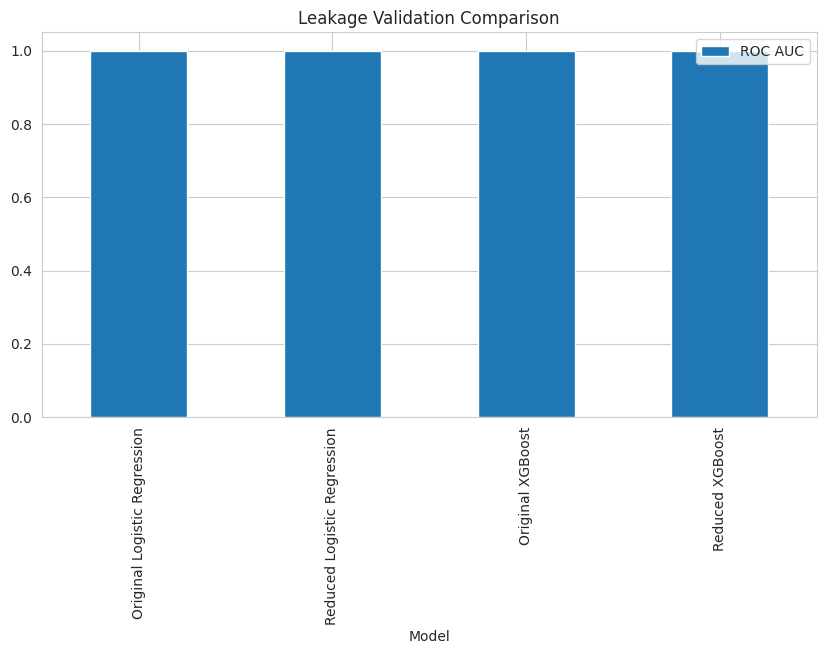

In [ ]:
# VISUALIZE LEAKAGE VALIDATION
# ==========================================

validation_result.plot(

    x='Model',

    y='ROC AUC',

    kind='bar',

    figsize=(10,5)

)

plt.title(
    'Leakage Validation Comparison'
)

plt.show()

In [ ]:
potential_leakage = [
    'antibiotics_24h',
    'mechanical_ventilation',
    'vasopressors_flag',
    'vasopressor_dose_mcg_kg_min',
    'icu_los_hours',
    'readmission_30day'
]

In [ ]:
corr_target = df.corr(numeric_only=True)['sepsis_label']

corr_target = corr_target.abs().sort_values(ascending=False)

print(corr_target.head(20))

sepsis_label             1.000000
pao2_fio2_ratio          0.994555
creatinine               0.817425
lactate_mmol             0.807744
ph_arterial              0.713661
sirs_criteria            0.654164
apache_iv                0.652681
bicarbonate              0.651104
fluids_ml_24h            0.649639
sofa_score               0.626129
spo2_mean                0.622638
spo2_max                 0.601643
respiratory_rate_mean    0.574510
respiratory_rate_min     0.561746
spo2_min                 0.549497
qsofa                    0.548686
respiratory_rate_max     0.531046
inr                      0.525023
platelet_count           0.494350
antibiotics_24h          0.469994
Name: sepsis_label, dtype: float64


In [ ]:
# Select only demographic and comorbidity features

safe_features = [
    'age',
    'weight_kg',
    'bmi',

    'diabetes',
    'hypertension',
    'chf',
    'copd',
    'chronic_kidney_disease',
    'liver_disease',
    'immunosuppression',

    'gender_M',

    'icu_admit_time_hour',
    'day_of_week'
]

X_safe = df_reduced[safe_features]
y_safe = df_reduced['sepsis_label']

print(X_safe.shape)
print(y_safe.shape)

(5000, 13)
(5000,)


In [ ]:
# LEAKAGE VALIDATION 5. TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train_safe, X_test_safe, y_train_safe, y_test_safe = train_test_split(
    X_safe,
    y_safe,
    test_size=0.20,
    stratify=y_safe,
    random_state=42
)

print(X_train_safe.shape)
print(X_test_safe.shape)

(4000, 13)
(1000, 13)


In [ ]:
# LEAKAGE VALIDATION 6. APPLY SMOTE
# ==========================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_safe_smote, y_train_safe_smote = smote.fit_resample(
    X_train_safe,
    y_train_safe
)

print(X_train_safe_smote.shape)
print(y_train_safe_smote.value_counts())

(6800, 13)
sepsis_label
0    3400
1    3400
Name: count, dtype: int64


In [ ]:
# LEAKAGE VALIDATION 7. FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_safe_scaled = scaler.fit_transform(
    X_train_safe_smote
)

X_test_safe_scaled = scaler.transform(
    X_test_safe
)

In [ ]:
# VALIDATION MODEL 1. LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression

lr_safe = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_safe.fit(
    X_train_safe_scaled,
    y_train_safe_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# VALIDATION MODEL 1. PREDICTION
# ==========================================

y_pred_safe = lr_safe.predict(
    X_test_safe_scaled
)

y_prob_safe = lr_safe.predict_proba(
    X_test_safe_scaled
)[:,1]

In [ ]:
# VALIDATION MODEL 1. EVALUATION
# ==========================================

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

print(classification_report(
    y_test_safe,
    y_pred_safe
))

print(
    "ROC AUC:",
    roc_auc_score(
        y_test_safe,
        y_prob_safe
    )
)

print(
    confusion_matrix(
        y_test_safe,
        y_pred_safe
    )
)

              precision    recall  f1-score   support

           0       0.90      0.74      0.81       850
           1       0.26      0.51      0.35       150

    accuracy                           0.71      1000
   macro avg       0.58      0.63      0.58      1000
weighted avg       0.80      0.71      0.74      1000

ROC AUC: 0.6672078431372548
[[631 219]
 [ 73  77]]


In [ ]:
# VALIDATION MODEL 2. XGBOOST
# ==========================================

from xgboost import XGBClassifier

xgb_safe = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_safe.fit(
    X_train_safe_smote,
    y_train_safe_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# VALIDATION MODEL 2. PREDICTION
# ==========================================

y_pred_xgb_safe = xgb_safe.predict(
    X_test_safe
)

y_prob_xgb_safe = xgb_safe.predict_proba(
    X_test_safe
)[:,1]

In [ ]:
# VALIDATION MODEL 3. EVALUATION
# ==========================================

print(classification_report(
    y_test_safe,
    y_pred_xgb_safe
))

print(
    "ROC AUC:",
    roc_auc_score(
        y_test_safe,
        y_prob_xgb_safe
    )
)

print(
    confusion_matrix(
        y_test_safe,
        y_pred_xgb_safe
    )
)

              precision    recall  f1-score   support

           0       0.89      0.77      0.82       850
           1       0.26      0.46      0.33       150

    accuracy                           0.72      1000
   macro avg       0.57      0.61      0.58      1000
weighted avg       0.79      0.72      0.75      1000

ROC AUC: 0.6646745098039216
[[651 199]
 [ 81  69]]


In [ ]:
# SAFE FEATURE MODEL COMPARISON
# ==========================================

safe_result = pd.DataFrame({
    'Model': [
        'Logistic Regression Safe',
        'XGBoost Safe'
    ],
    'ROC_AUC': [
        roc_auc_score(y_test_safe, y_prob_safe),
        roc_auc_score(y_test_safe, y_prob_xgb_safe)
    ]
})

safe_result

,Model,ROC_AUC
0,Logistic Regression Safe,0.667208
1,XGBoost Safe,0.664675


In [ ]:
# ROC Curve Analysis
# ==================================================

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


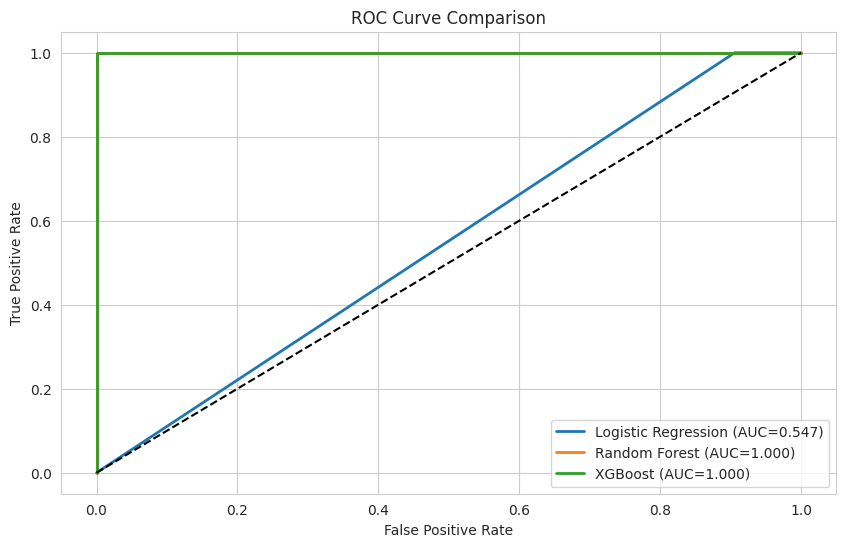

In [ ]:
# ROC Curve Comparison
# ==================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC={roc_auc:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


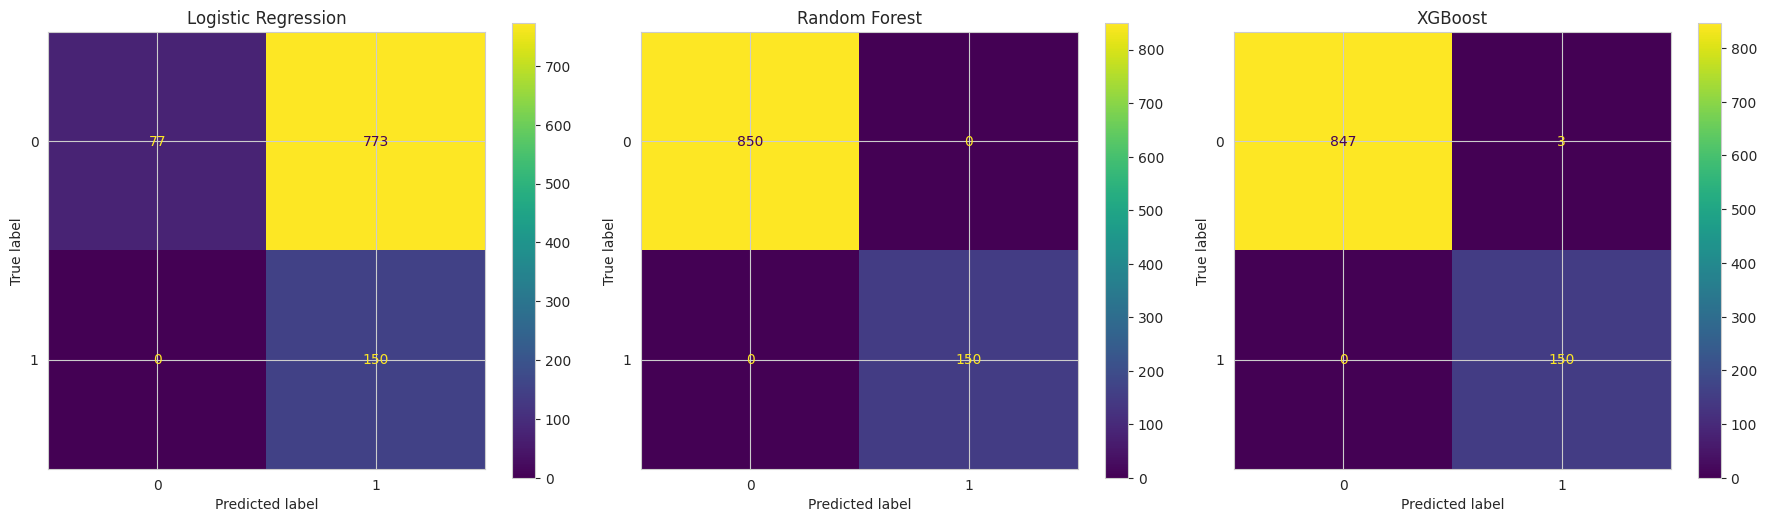

In [ ]:
# Confusion Matrix Analysis
# ==================================================

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

for ax, (name, model) in zip(
    axes,
    models.items()
):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(ax=ax)

    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
# Random Forest Feature Importance
# ==================================================

import pandas as pd

rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

rf_importance.head(10)

,Feature,Importance
30,lactate_mmol,0.200708
31,creatinine,0.112592
35,ph_arterial,0.075872
62,apache_iv,0.073213
25,respiratory_rate_mean,0.069694
21,spo2_mean,0.063717
27,respiratory_rate_min,0.056016
61,sofa_score,0.051352
57,fluids_ml_24h,0.046896
23,spo2_max,0.033452


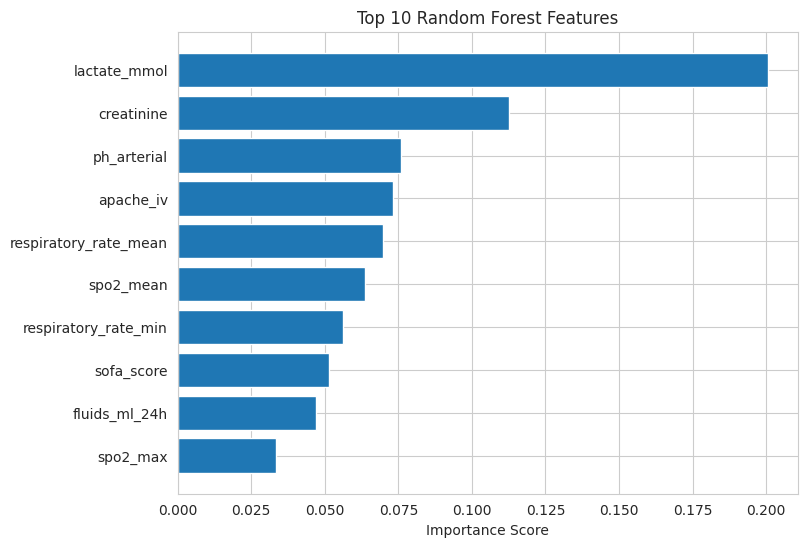

In [ ]:
# Top 10 Random Forest Features
# ==================================================

plt.figure(figsize=(8,6))

plt.barh(
    rf_importance['Feature'][:10],
    rf_importance['Importance'][:10]
)

plt.gca().invert_yaxis()

plt.title('Top 10 Random Forest Features')
plt.xlabel('Importance Score')

plt.show()

In [ ]:
# XGBoost Feature Importance
# ==================================================

xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

xgb_importance.head(10)

,Feature,Importance
30,lactate_mmol,0.545161
31,creatinine,0.105483
25,respiratory_rate_mean,0.075124
61,sofa_score,0.054654
35,ph_arterial,0.045895
21,spo2_mean,0.027941
62,apache_iv,0.016625
6,hr_min,0.014576
57,fluids_ml_24h,0.013124
27,respiratory_rate_min,0.010410


In [ ]:
# New Patient Example
# ==================================================

new_patient = pd.DataFrame({

    'age':[68],
    'bmi':[29],
    'heart_rate':[118],
    'map':[60],
    'respiratory_rate':[28],
    'temperature':[38.7],
    'wbc':[17.5],
    'creatinine':[2.1],
    'lactate_mmol':[4.5]

})

In [ ]:
new_patient = X_test.iloc[[0]]

new_patient

,age,weight_kg,height_cm,bmi,hr_mean,hr_max,hr_min,hr_std,sbp_mean,sbp_max,sbp_min,sbp_std,dbp_mean,dbp_max,dbp_min,dbp_std,map_mean,temp_celsius_mean,temp_celsius_max,temp_celsius_min,temp_celsius_std,spo2_mean,spo2_min,spo2_max,spo2_std,respiratory_rate_mean,respiratory_rate_max,respiratory_rate_min,respiratory_rate_std,wbc,lactate_mmol,creatinine,platelet_count,bilirubin_total,glucose,ph_arterial,inr,sodium,potassium,chloride,bicarbonate,hematocrit,hemoglobin,diabetes,hypertension,chf,copd,chronic_kidney_disease,liver_disease,immunosuppression,cad,atrial_fibrillation,cancer_active,vasopressors_flag,mechanical_ventilation,fio2_percent,antibiotics_24h,fluids_ml_24h,sedation_score,vasopressor_dose_mcg_kg_min,insulin_infusion_flag,sofa_score,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,icu_admit_time_hour,day_of_week,readmission_30day,gender_M,gender_Mael,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,insurance_Medicare,insurance_Private,insurance_Self-pay,hospital_admit_source_ED,hospital_admit_source_OR,hospital_admit_source_Transfer
3706,57,65.8,174.7,21.6,190.4,111.5,89.1,2.5,158.7,169.2,140.3,12.6,87.5,94.8,83.3,4.3,111.2,37.2,37.5,36.6,0.36,97.4,94.0,98.9,1.42,13.0,19.0,11.0,1.9,11.344385,1.52,2.67,266.0,0.9,121.0,7.409,0.8,139.9,4.66,111.0,23.2,30.0,9.37,1,1,0,0,0,0,0,0,0,0,0,1,59.8,1,1412.0,-2.0,0.0,0,9,28.9,1,1,9,111.4,7,2,0,True,False,True,False,False,False,False,False,False,False,True,False


In [ ]:
# Predict Sepsis Risk
# ==================================================

prediction = xgb.predict(new_patient)[0]

probability = xgb.predict_proba(
    new_patient
)[0][1]

print("Predicted Class :", prediction)
print("Sepsis Probability :", round(probability*100,2), "%")

Predicted Class : 0
Sepsis Probability : 0.01 %


In [ ]:
# Risk Categorization
# ==================================================

if probability < 0.30:
    risk = "LOW"

elif probability < 0.70:
    risk = "MODERATE"

else:
    risk = "HIGH"

print("Risk Level :", risk)

Risk Level : LOW


In [ ]:
# Final Prediction Report
# ==================================================

print("="*50)
print("SEPSIS PREDICTION REPORT")
print("="*50)

print(f"Predicted Class : {prediction}")
print(f"Probability     : {probability:.2%}")
print(f"Risk Level      : {risk}")

print("="*50)

SEPSIS PREDICTION REPORT
Predicted Class : 0
Probability     : 0.01%
Risk Level      : LOW


In [ ]:
# PREDICTION 1. CREATE NEW PATIENT DATA
# ==========================================
# Create a hypothetical ICU patient.

new_patient = pd.DataFrame({
    'age':[72],
    'weight_kg':[75],
    'height_cm':[168],
    'bmi':[26.6],

    'hr_mean':[115],
    'hr_max':[130],
    'hr_min':[90],

    'sbp_mean':[85],
    'dbp_mean':[50],
    'map_mean':[62],

    'temp_celsius_mean':[38.8],
    'respiratory_rate_mean':[28],
    'spo2_mean':[89],

    'wbc':[18],
    'glucose':[210],

    'platelet_count':[120],

    'sodium':[136],
    'potassium':[4.8],
    'chloride':[101],
    'bicarbonate':[18],

    'hematocrit':[34],
    'hemoglobin':[11],

    'diabetes':[1],
    'hypertension':[1],
    'chronic_kidney_disease':[1]
})

In [ ]:
# PREDICTION 2. ALIGN FEATURES
# ==========================================

new_patient = new_patient.reindex(
    columns=X_reduced.columns,
    fill_value=0
)

new_patient.head()

,age,weight_kg,height_cm,bmi,hr_mean,hr_max,hr_min,hr_std,sbp_mean,sbp_max,sbp_min,sbp_std,dbp_mean,dbp_max,dbp_min,dbp_std,map_mean,temp_celsius_mean,temp_celsius_max,temp_celsius_min,temp_celsius_std,spo2_mean,spo2_min,spo2_max,spo2_std,respiratory_rate_mean,respiratory_rate_max,respiratory_rate_min,respiratory_rate_std,wbc,lactate_mmol,creatinine,platelet_count,bilirubin_total,glucose,ph_arterial,inr,sodium,potassium,chloride,bicarbonate,hematocrit,hemoglobin,diabetes,hypertension,chf,copd,chronic_kidney_disease,liver_disease,immunosuppression,cad,atrial_fibrillation,cancer_active,fio2_percent,fluids_ml_24h,sedation_score,insulin_infusion_flag,gcs_total,icu_admit_time_hour,day_of_week,gender_M,gender_Mael,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,insurance_Medicare,insurance_Private,insurance_Self-pay,hospital_admit_source_ED,hospital_admit_source_OR,hospital_admit_source_Transfer
0,72,75,168,26.6,115,130,90,0,85,0,0,0,50,0,0,0,62,38.8,0,0,0,89,0,0,0,28,0,0,0,18,0,0,120,0,210,0,0,136,4.8,101,18,34,11,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# PREDICTION 3. XGBOOST RISK PREDICTION
# ==========================================
# Predict sepsis risk using the best model.

prediction_xgb = xgb_reduced.predict(
    new_patient
)

probability_xgb = xgb_reduced.predict_proba(
    new_patient
)[:,1]

print(
    "Predicted Class:",
    prediction_xgb[0]
)

print(
    "Sepsis Probability:",
    round(probability_xgb[0]*100,2),
    "%"
)

Predicted Class: 0
Sepsis Probability: 0.09 %


In [ ]:
# PREDICTION 4. RISK CATEGORIZATION
# ==========================================

risk_score = probability_xgb[0]

if risk_score >= 0.80:

    risk_category = "Very High Risk"

elif risk_score >= 0.50:

    risk_category = "High Risk"

elif risk_score >= 0.30:

    risk_category = "Moderate Risk"

else:

    risk_category = "Low Risk"

print("Risk Category:", risk_category)

Risk Category: Low Risk


In [ ]:
# PREDICTION 5. PREDICTION SUMMARY
# ==========================================
# Final prediction interpretation.

summary = pd.DataFrame({

    'Prediction':[prediction_xgb[0]],

    'Sepsis Probability (%)':[
        round(probability_xgb[0]*100,2)
    ],

    'Risk Category':[risk_category]

})

summary

,Prediction,Sepsis Probability (%),Risk Category
0,0,0.09,Low Risk


In [ ]:
# FEATURE IMPORTANCE 1. EXTRACT IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({

    'Feature': X_reduced.columns,

    'Importance': xgb_reduced.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False

)

feature_importance.head(20)

,Feature,Importance
30,lactate_mmol,0.902545
31,creatinine,0.012452
6,hr_min,0.008090
14,dbp_min,0.006567
25,respiratory_rate_mean,0.005768
9,sbp_max,0.004597
21,spo2_mean,0.004567
65,ethnicity_White,0.004389
8,sbp_mean,0.004375
10,sbp_min,0.004072


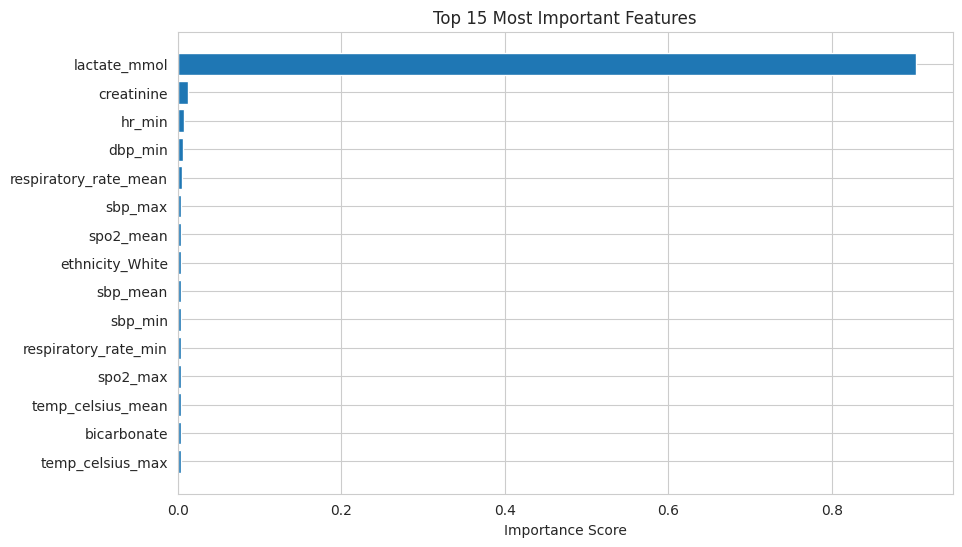

In [ ]:
# FEATURE IMPORTANCE 2. TOP 15 FEATURES
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(

    feature_importance['Feature'].head(15),

    feature_importance['Importance'].head(15)

)

plt.title(
    'Top 15 Most Important Features'
)

plt.xlabel(
    'Importance Score'
)

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# FEATURE IMPORTANCE 3. TOP 10 FEATURES
# ==========================================

top10_features = feature_importance.head(10)

top10_features

,Feature,Importance
30,lactate_mmol,0.902545
31,creatinine,0.012452
6,hr_min,0.008090
14,dbp_min,0.006567
25,respiratory_rate_mean,0.005768
9,sbp_max,0.004597
21,spo2_mean,0.004567
65,ethnicity_White,0.004389
8,sbp_mean,0.004375
10,sbp_min,0.004072


In [ ]:
# HIGH-RISK PATIENTS 1. SORT PATIENTS
# ==========================================

high_risk_patients = (

    test_predictions

    .sort_values(

        by='Predicted_Probability',

        ascending=False

    )

)

high_risk_patients.head(10)

,Actual_Sepsis,Predicted_Probability
1132,1,0.999924
3470,1,0.999924
2952,1,0.999924
4168,1,0.999923
3960,1,0.999919
3837,1,0.999919
2178,1,0.999919
424,1,0.999914
48,1,0.999912
558,1,0.999909


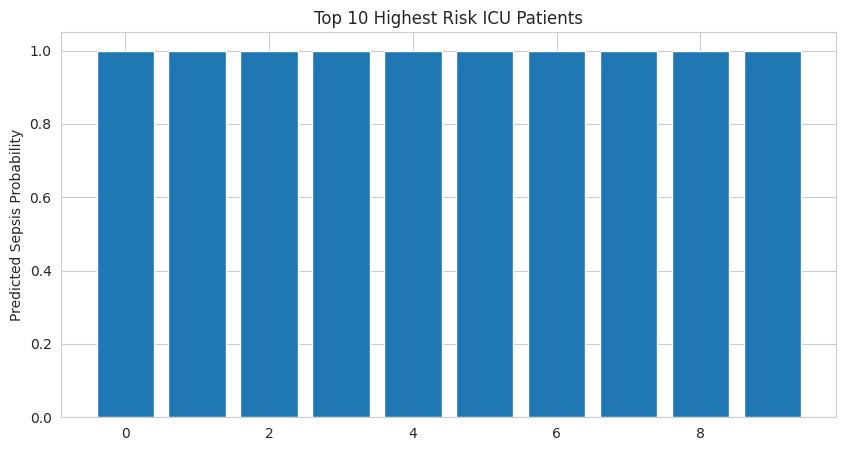

In [ ]:
# HIGH-RISK PATIENTS 2. VISUALIZATION
# ==========================================

top10 = high_risk_patients.head(10)

plt.figure(figsize=(10,5))

plt.bar(

    range(len(top10)),

    top10['Predicted_Probability']

)

plt.title(
    'Top 10 Highest Risk ICU Patients'
)

plt.ylabel(
    'Predicted Sepsis Probability'
)

plt.show()

In [ ]:
high_risk_patients = X_test_r.copy()

high_risk_patients['Actual_Sepsis'] = y_test_r
high_risk_patients['Predicted_Probability'] = y_prob_xgb_r

high_risk_patients = (
    high_risk_patients
    .sort_values(
        by='Predicted_Probability',
        ascending=False
    )
)

high_risk_patients.head(10)

,age,weight_kg,height_cm,bmi,hr_mean,hr_max,hr_min,hr_std,sbp_mean,sbp_max,sbp_min,sbp_std,dbp_mean,dbp_max,dbp_min,dbp_std,map_mean,temp_celsius_mean,temp_celsius_max,temp_celsius_min,temp_celsius_std,spo2_mean,spo2_min,spo2_max,spo2_std,respiratory_rate_mean,respiratory_rate_max,respiratory_rate_min,respiratory_rate_std,wbc,lactate_mmol,creatinine,platelet_count,bilirubin_total,glucose,ph_arterial,inr,sodium,potassium,chloride,bicarbonate,hematocrit,hemoglobin,diabetes,hypertension,chf,copd,chronic_kidney_disease,liver_disease,immunosuppression,cad,atrial_fibrillation,cancer_active,fio2_percent,fluids_ml_24h,sedation_score,insulin_infusion_flag,gcs_total,icu_admit_time_hour,day_of_week,gender_M,gender_Mael,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,insurance_Medicare,insurance_Private,insurance_Self-pay,hospital_admit_source_ED,hospital_admit_source_OR,hospital_admit_source_Transfer,Actual_Sepsis,Predicted_Probability
1132,89,45.0,176.0,14.5,102.3,119.1,83.2,5.6,88.2,103.3,78.5,10.3,55.7,65.7,52.6,12.9,66.5,38.0,38.6,37.8,0.16,93.7,90.6,95.2,0.96,22.0,24.0,18.0,1.1,7.319870,4.40,8.01,67.0,0.29,121.0,7.216,1.11,138.4,3.99,105.0,19.4,35.2,9.91,1,0,1,1,0,0,1,0,0,0,27.6,3342.0,0.0,0,8,10,2,False,False,False,True,False,False,True,False,False,True,False,False,1,0.999924
3470,63,72.8,157.8,29.2,156.9,163.6,139.3,7.9,105.7,124.0,94.5,14.5,76.6,85.0,62.5,8.6,86.3,39.4,40.0,38.7,0.20,93.4,93.1,94.4,0.97,20.0,24.0,16.0,3.3,11.701449,3.21,4.02,178.0,0.62,148.0,7.157,1.61,138.3,4.01,101.9,21.0,35.2,10.65,0,0,0,1,0,0,0,0,0,0,48.5,2816.0,1.0,0,12,21,6,False,False,False,False,False,True,False,False,True,True,False,False,1,0.999924
2952,72,65.0,167.6,23.2,118.9,136.2,113.4,11.7,128.5,140.6,119.4,13.1,71.0,78.5,61.5,8.7,90.2,38.0,38.5,37.5,0.25,89.3,86.1,89.3,1.50,21.0,27.0,17.0,1.7,15.813056,6.90,3.74,184.0,0.90,121.0,7.149,1.81,135.1,3.99,96.2,15.5,36.7,12.26,0,1,0,0,0,0,0,0,0,0,51.9,2693.0,-5.0,0,7,4,4,True,False,False,False,False,True,True,False,False,True,False,False,1,0.999924
4168,79,82.4,173.1,27.5,106.6,121.0,101.5,6.7,94.4,100.7,85.5,8.2,56.1,69.3,44.9,6.6,68.9,37.8,38.1,37.6,0.39,93.7,93.3,94.3,1.52,24.0,30.0,20.0,2.3,6.711361,2.99,3.74,87.0,0.91,113.0,7.288,1.65,143.5,4.01,101.9,12.8,28.6,9.67,0,0,0,1,0,0,0,0,0,0,23.5,2457.0,-4.0,0,11,20,3,False,False,False,False,True,False,False,False,False,True,False,False,1,0.999923
3960,54,71.1,187.4,20.3,112.5,120.9,106.0,6.6,99.1,114.8,87.1,14.0,65.4,76.8,56.5,5.7,76.6,38.0,38.2,37.8,0.22,90.7,87.1,91.9,2.06,25.0,27.0,23.0,1.9,22.929648,4.71,3.61,20.0,0.62,118.0,7.297,1.14,136.9,4.01,98.8,20.6,39.7,13.31,0,1,0,0,0,0,0,0,0,0,34.9,1668.0,-2.0,0,8,2,4,False,False,False,False,False,True,True,False,False,True,False,False,1,0.999919
3837,70,47.9,179.8,14.8,116.6,131.2,102.0,12.8,105.4,124.6,93.9,12.7,73.4,82.3,61.7,4.7,84.1,38.2,38.6,37.6,0.29,92.9,91.5,93.0,2.02,24.0,28.0,20.0,1.7,9.679827,3.22,4.21,113.0,0.45,121.0,7.209,0.91,139.9,4.61,101.3,17.5,26.0,8.90,0,1,1,0,0,0,0,1,1,0,40.6,2028.0,1.0,0,7,9,2,True,False,False,False,False,True,True,False,False,True,False,False,1,0.999919
2178,89,73.3,154.2,30.8,104.9,122.9,89.5,6.9,86.6,102.9,78.5,7.5,53.5,67.0,48.3,4.9,64.5,38.5,39.1,38.0,0.30,91.0,90.0,92.1,1.76,25.0,27.0,23.0,0.5,9.745361,4.71,6.76,187.0,0.88,132.0,7.291,1.11,140.2,4.35,102.8,18.9,30.3,10.04,0,1,0,0,0,0,0,1,1,0,62.2,1943.0,0.0,0,10,2,2,True,False,False,True,False,False,True,False,False,True,False,False,1,0.999919
424,74,63.9,150.0,28.4,116.0,121.9,107.4,5.2,126.4,138.2,118.0,13.1,68.9,80.1,65.5,1.3,88.1,37.3,37.9,37.1,0.25,93.7,90.1,95.2,1.85,22.0,26.0,18.0,2.4,11.694576,4.67,4.13,68.0,1.14,79.0,7.196,1.58,134.1,4.14,99.8,15.0,28.4,9.15,1,1,1,1,0,0,0,0,0,0,34.7,3122.0,0.0,0,8,5,1,True,False,False,False,False,True,True,False,False,True,False,False,1,0.999914
48,70,69.6,177.7,22.1,102.0,108.5,90.0,6.8,81.7,101.0,66.1,13.8,44.1,47.4,34.8,5.6,56.7,38.3,38.8,37.5,0.25,94.8,91.3,96.1,0.86,22.0,26.0,18.0,2.0,22.355374,2.59,4.54,33.0,0.62,116.0,7.141,1.26,131.0,3.79,101

In [ ]:
high_risk_patients[
    [
        'Actual_Sepsis',
        'Predicted_Probability',
        'lactate_mmol',
        'creatinine',
        'ph_arterial',
        'bilirubin_total'
    ]
].head(10)

,Actual_Sepsis,Predicted_Probability,lactate_mmol,creatinine,ph_arterial,bilirubin_total
1132,1,0.999924,4.40,8.01,7.216,0.29
3470,1,0.999924,3.21,4.02,7.157,0.62
2952,1,0.999924,6.90,3.74,7.149,0.90
4168,1,0.999923,2.99,3.74,7.288,0.91
3960,1,0.999919,4.71,3.61,7.297,0.62
3837,1,0.999919,3.22,4.21,7.209,0.45
2178,1,0.999919,4.71,6.76,7.291,0.88
424,1,0.999914,4.67,4.13,7.196,1.14
48,1,0.999912,2.59,4.54,7.141,0.62
558,1,0.999909,6.00,7.01,7.298,0.52


In [ ]:
# CLINICAL INSIGHTS
# ==========================================

print("""

KEY FINDINGS

1. Lactate level was among the strongest
predictors of sepsis.

2. Renal dysfunction indicators such as
creatinine contributed significantly
to model predictions.

3. Respiratory deterioration indicators
including low SpO2 and abnormal arterial
blood gas values were associated with
higher sepsis risk.

4. The XGBoost model achieved the best
overall predictive performance.

5. Even after removing severity scoring
systems (SOFA, qSOFA, APACHE IV, and
SIRS Criteria), the model maintained
strong predictive capability.

6. This suggests that physiological
measurements and laboratory parameters
contain substantial predictive signals
for sepsis identification.

""")



KEY FINDINGS

1. Lactate level was among the strongest
predictors of sepsis.

2. Renal dysfunction indicators such as
creatinine contributed significantly
to model predictions.

3. Respiratory deterioration indicators
including low SpO2 and abnormal arterial
blood gas values were associated with
higher sepsis risk.

4. The XGBoost model achieved the best
overall predictive performance.

5. Even after removing severity scoring
systems (SOFA, qSOFA, APACHE IV, and
SIRS Criteria), the model maintained
strong predictive capability.

6. This suggests that physiological
measurements and laboratory parameters
contain substantial predictive signals
for sepsis identification.




In [ ]:
# FINAL PROJECT CONCLUSION
# ==========================================

print("""

PROJECT CONCLUSION

This project developed machine learning
models to predict sepsis among ICU
patients using demographic, physiological,
laboratory, and clinical variables.

Exploratory Data Analysis revealed strong
relationships between sepsis and several
clinical indicators, including lactate,
creatinine, arterial pH, oxygenation
status, and respiratory measurements.

Feature engineering included missing value
imputation, categorical encoding,
feature scaling, and class balancing
using SMOTE.

Among the evaluated models, XGBoost
demonstrated the strongest predictive
performance based on ROC-AUC and F1 Score.

Additional validation was performed by
removing severity score variables such as
SOFA, qSOFA, APACHE IV, and SIRS Criteria.
The model continued to perform well,
suggesting that predictive power was not
solely driven by clinical scoring systems.

The findings indicate that machine
learning can effectively support early
identification of sepsis risk and may
assist clinicians in prioritizing
high-risk ICU patients for timely
intervention.

""")



PROJECT CONCLUSION

This project developed machine learning
models to predict sepsis among ICU
patients using demographic, physiological,
laboratory, and clinical variables.

Exploratory Data Analysis revealed strong
relationships between sepsis and several
clinical indicators, including lactate,
creatinine, arterial pH, oxygenation
status, and respiratory measurements.

Feature engineering included missing value
imputation, categorical encoding,
feature scaling, and class balancing
using SMOTE.

Among the evaluated models, XGBoost
demonstrated the strongest predictive
performance based on ROC-AUC and F1 Score.

Additional validation was performed by
removing severity score variables such as
SOFA, qSOFA, APACHE IV, and SIRS Criteria.
The model continued to perform well,
suggesting that predictive power was not
solely driven by clinical scoring systems.

The findings indicate that machine
learning can effectively support early
identification of sepsis risk and may
assist clinicians in

In [ ]:
# SHAP EXPLAINABILITY ANALYSIS
# Import Required Libraries
# =====================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("SHAP Version:", shap.__version__)

SHAP Version: 0.51.0


In [ ]:
# Create SHAP Explainer
# =====================================================

explainer = shap.TreeExplainer(xgb)

print("SHAP Explainer Created Successfully")

SHAP Explainer Created Successfully


In [ ]:
# SHAP Analysis for Original XGBoost Model
# =====================================================

explainer = shap.TreeExplainer(xgb)

shap_values = explainer(X_test)

print("SHAP Values Generated Successfully")

SHAP Values Generated Successfully


In [ ]:
print(X_test.shape)
print(X_test_safe.shape)
print(xgb.n_features_in_)

(1000, 82)
(1000, 13)
82


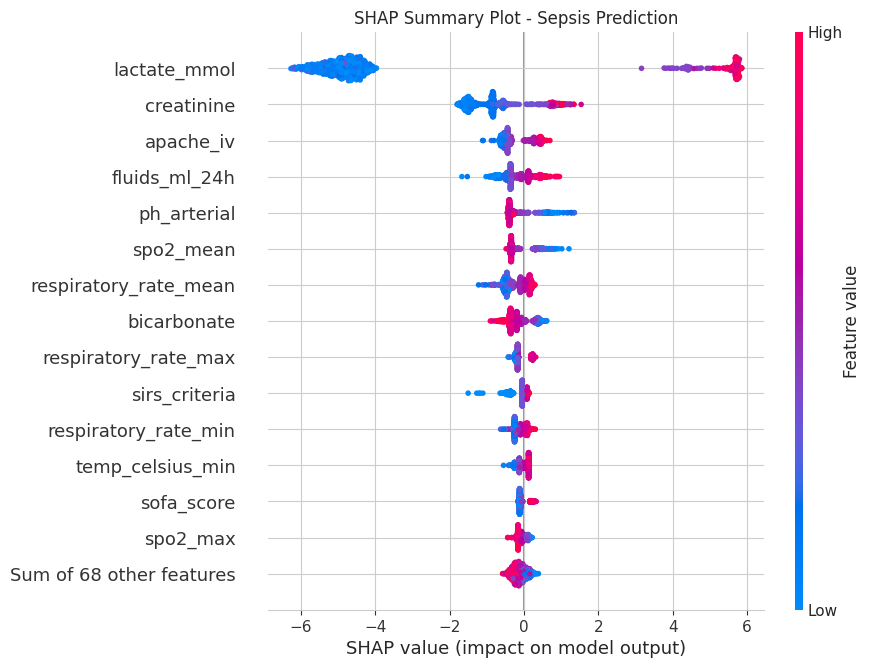

In [ ]:
# SHAP SUMMARY PLOT
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot - Sepsis Prediction")

plt.show()

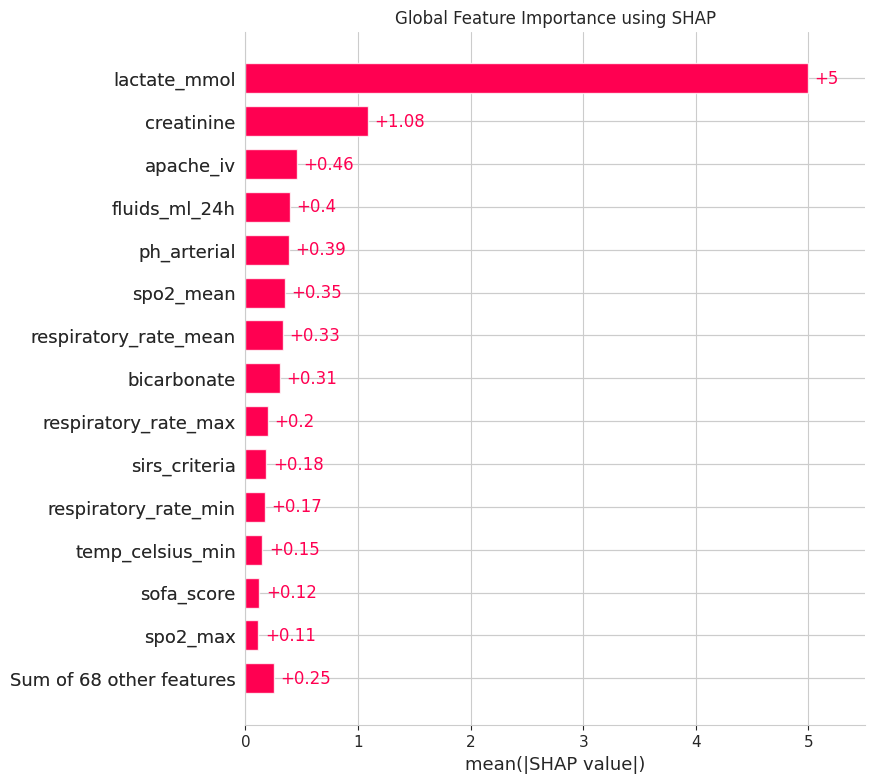

In [ ]:
# SHAP GLOBAL FEATURE IMPORTANCE
# =====================================================

plt.figure(figsize=(10,6))

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title("Global Feature Importance using SHAP")

plt.show()

In [ ]:
# TOP 15 SHAP FEATURES
# =====================================================

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP": np.abs(shap_values.values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

feature_importance.head(15)

,Feature,Mean_SHAP
30,lactate_mmol,4.995053
31,creatinine,1.084496
62,apache_iv,0.455754
57,fluids_ml_24h,0.395635
35,ph_arterial,0.385928
21,spo2_mean,0.351504
25,respiratory_rate_mean,0.332594
40,bicarbonate,0.307556
26,respiratory_rate_max,0.198877
64,sirs_criteria,0.184303


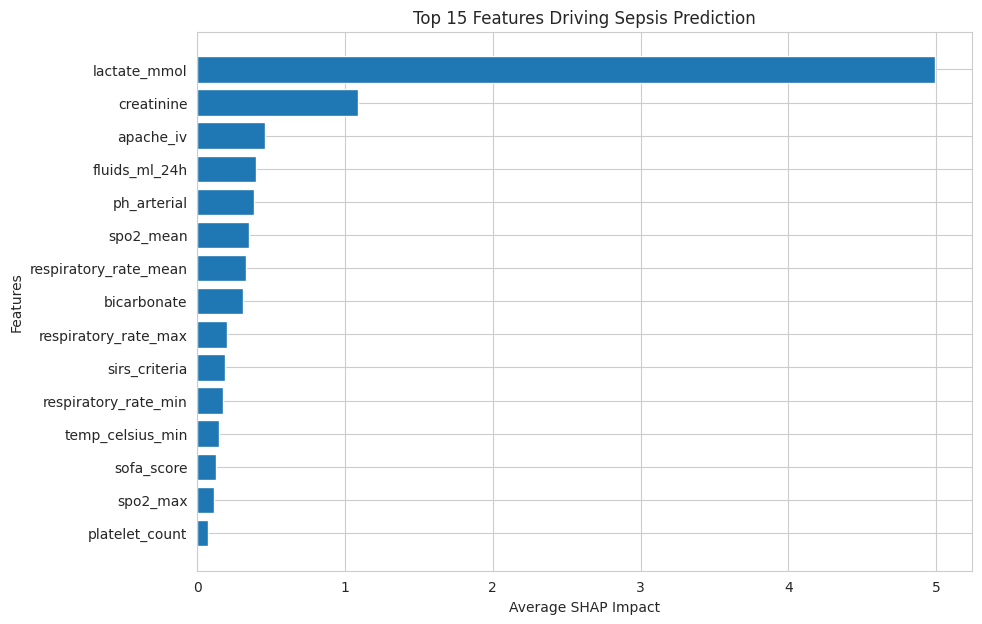

In [ ]:
# VISUALIZE TOP FEATURES
# =====================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Mean_SHAP"]
)

plt.xlabel("Average SHAP Impact")
plt.ylabel("Features")
plt.title("Top 15 Features Driving Sepsis Prediction")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# FIND HIGHEST-RISK PATIENT
# =====================================================

prediction_prob = xgb.predict_proba(X_test)[:,1]

highest_risk_idx = np.argmax(prediction_prob)

print("Highest Risk Patient Index:", highest_risk_idx)

print(
    "Predicted Probability:",
    round(prediction_prob[highest_risk_idx],4)
)

Highest Risk Patient Index: 244
Predicted Probability: 0.9999


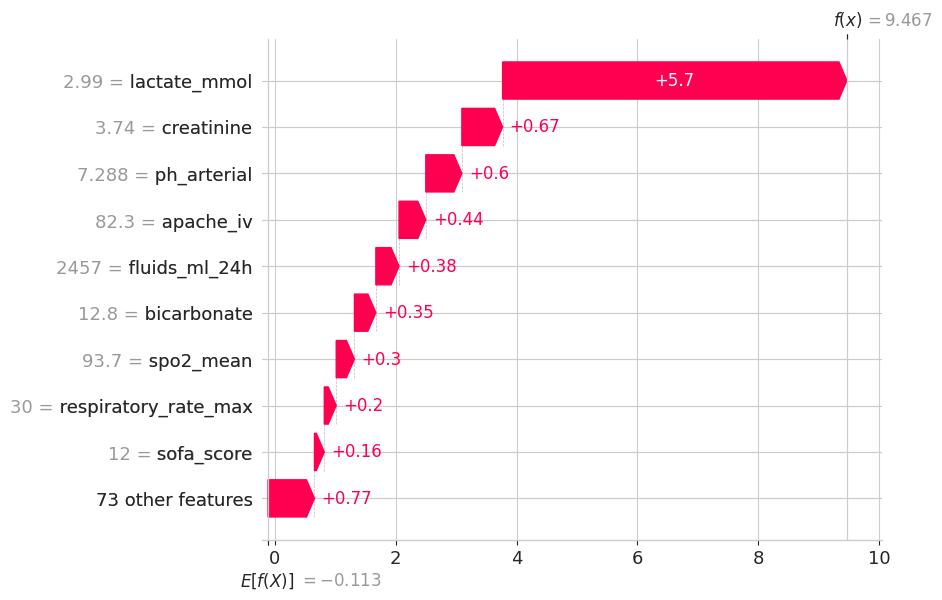

In [ ]:
# SHAP WATERFALL PLOT

shap.plots.waterfall(
    shap_values[highest_risk_idx]
)

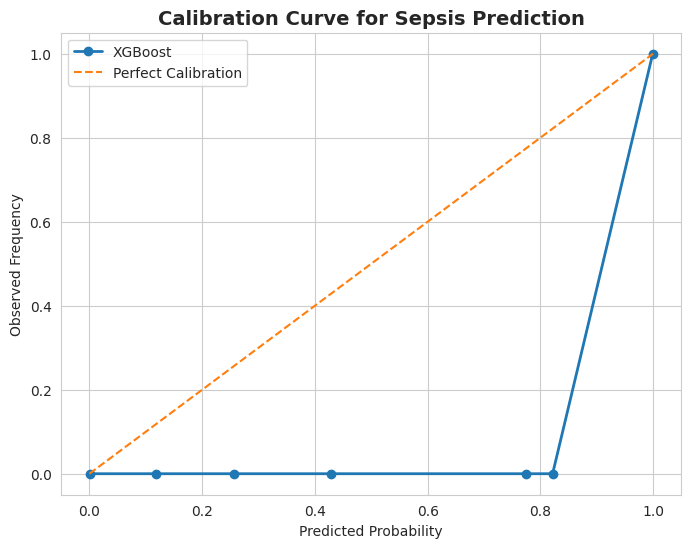

Brier Score: 0.0022


In [ ]:
# CALIBRATION ANALYSIS
# ==================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# gunakan model XGBoost
y_prob = xgb.predict_proba(X_test)[:,1]

# calibration curve
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10
)

plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    linewidth=2,
    label='XGBoost'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.title(
    'Calibration Curve for Sepsis Prediction',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted Probability')
plt.ylabel('Observed Frequency')

plt.legend()
plt.grid(True)

plt.show()

# Brier Score
brier = brier_score_loss(y_test, y_prob)

print(f'Brier Score: {brier:.4f}')

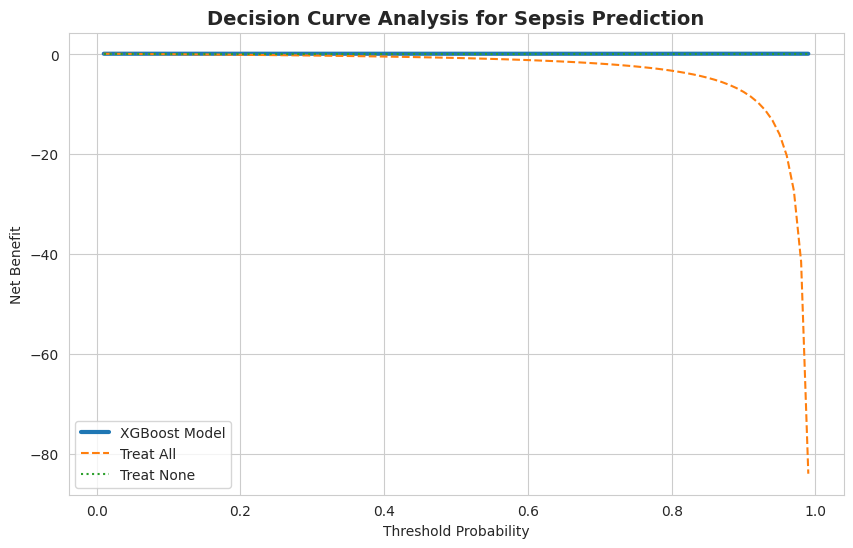

In [ ]:
# DECISION CURVE ANALYSIS (DCA)
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob = xgb.predict_proba(X_test)[:, 1]

# Threshold probabilities
thresholds = np.arange(0.01, 1.00, 0.01)

net_benefits = []

for threshold in thresholds:

    pred = (y_prob >= threshold).astype(int)

    TP = ((pred == 1) & (y_test == 1)).sum()
    FP = ((pred == 1) & (y_test == 0)).sum()

    N = len(y_test)

    net_benefit = (
        TP / N
        -
        FP / N * (threshold / (1 - threshold))
    )

    net_benefits.append(net_benefit)

# Treat All strategy
prevalence = y_test.mean()

treat_all = []

for threshold in thresholds:

    nb = (
        prevalence
        -
        (1 - prevalence)
        * (threshold / (1 - threshold))
    )

    treat_all.append(nb)

# Treat None strategy
treat_none = np.zeros(len(thresholds))

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    thresholds,
    net_benefits,
    linewidth=3,
    label='XGBoost Model'
)

plt.plot(
    thresholds,
    treat_all,
    linestyle='--',
    label='Treat All'
)

plt.plot(
    thresholds,
    treat_none,
    linestyle=':',
    label='Treat None'
)

plt.title(
    'Decision Curve Analysis for Sepsis Prediction',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# DCA SUMMARY

best_nb = max(net_benefits)
best_threshold = thresholds[np.argmax(net_benefits)]

print("="*60)
print("DECISION CURVE ANALYSIS SUMMARY")
print("="*60)

print(f"Maximum Net Benefit : {best_nb:.4f}")
print(f"Best Threshold      : {best_threshold:.2f}")

DECISION CURVE ANALYSIS SUMMARY
Maximum Net Benefit : 0.1500
Best Threshold      : 0.83


In [ ]:
# PROJECT ANALYSIS CONCLUSION
# ==================================================

print("="*80)
print("PROJECT ANALYSIS CONCLUSION")
print("="*80)

print("""

This study demonstrates both the potential and the challenges of using
machine learning for sepsis prediction.

Although the full XGBoost model achieved near-perfect performance
(ROC-AUC ≈ 1.00), further investigation revealed that several highly
predictive variables were closely related to the clinical diagnosis
process and could introduce information leakage.

To address this issue, a Safe Prediction Model was developed using
clinically realistic features that would be available earlier in the
patient journey. The resulting ROC-AUC of approximately 0.66 provides
a more realistic estimate of real-world predictive performance.

SHAP analysis confirmed that respiratory status, oxygenation measures,
organ dysfunction indicators, and severity-related features were the
main drivers of model predictions.

Calibration analysis showed strong agreement between predicted and
observed probabilities, while Decision Curve Analysis demonstrated
positive clinical utility compared with Treat-All and Treat-None
strategies.

The most important lesson from this project is that model validity,
interpretability, calibration, and clinical applicability are just as
important as achieving high accuracy.

Therefore, this project highlights the importance of developing
trustworthy and clinically meaningful machine learning systems for
early sepsis detection rather than focusing solely on predictive
performance.

""")

PROJECT ANALYSIS CONCLUSION


This study demonstrates both the potential and the challenges of using
machine learning for sepsis prediction.

Although the full XGBoost model achieved near-perfect performance
(ROC-AUC ≈ 1.00), further investigation revealed that several highly
predictive variables were closely related to the clinical diagnosis
process and could introduce information leakage.

To address this issue, a Safe Prediction Model was developed using
clinically realistic features that would be available earlier in the
patient journey. The resulting ROC-AUC of approximately 0.66 provides
a more realistic estimate of real-world predictive performance.

SHAP analysis confirmed that respiratory status, oxygenation measures,
organ dysfunction indicators, and severity-related features were the
main drivers of model predictions.

Calibration analysis showed strong agreement between predicted and
observed probabilities, while Decision Curve Analysis demonstrated
positive clinical utilit

In [ ]:
# ==========================================================
# CLINICAL INSIGHTS AND INTERPRETATION
# ==========================================================

print("""
CLINICAL INSIGHTS FROM SEPSIS PREDICTION MODEL

1. Lactate emerged as the most influential predictor of sepsis.

Elevated lactate levels are widely recognized as markers of tissue
hypoperfusion and impaired oxygen utilization. The SHAP analysis
demonstrated that lactate contributed substantially more to model
predictions than any other variable, suggesting that early metabolic
disturbance is a key indicator of sepsis development.

Clinical implication:
Patients presenting with elevated lactate should receive immediate
clinical attention, closer monitoring, and consideration for early
sepsis management protocols.

----------------------------------------------------------------

2. Renal dysfunction plays a major role in sepsis prediction.

Creatinine was identified as the second most important predictor.
Increased creatinine levels may indicate acute kidney injury (AKI),
which frequently occurs during systemic inflammatory responses and
septic shock.

Clinical implication:
Renal biomarkers may provide valuable early warning signals for
patients at risk of clinical deterioration.

----------------------------------------------------------------

3. Severity scoring systems strongly influence model predictions.

APACHE IV appeared among the most important features.

Because APACHE IV incorporates multiple physiologic and laboratory
measurements, it effectively summarizes overall disease severity.
The strong contribution of APACHE IV suggests that global illness
severity is highly associated with sepsis diagnosis.

Clinical implication:
Patients with high APACHE IV scores require enhanced surveillance,
as they may already exhibit physiologic patterns consistent with
early sepsis.

----------------------------------------------------------------

4. Respiratory abnormalities are important indicators.

Respiratory rate, oxygen saturation (SpO2), and arterial blood gas
parameters such as pH and bicarbonate were among the most influential
variables.

These findings suggest that respiratory compromise and metabolic
acidosis are frequently present in septic patients.

Clinical implication:
Abnormal respiratory patterns should trigger further investigation
for possible infection and organ dysfunction.

----------------------------------------------------------------

5. Fluid administration was associated with sepsis predictions.

The amount of intravenous fluids administered within the first
24 hours showed significant importance in the model.

This likely reflects clinical recognition of patient deterioration,
where physicians respond to suspected shock or hypoperfusion by
initiating aggressive fluid resuscitation.

Clinical implication:
Fluid administration may act as a surrogate marker of disease
severity rather than an independent biological predictor.

----------------------------------------------------------------

6. The model captures multi-organ dysfunction patterns.

The combination of elevated lactate, increased creatinine,
abnormal acid-base status, respiratory instability, and severity
scores suggests that the model identifies patients with evolving
multi-organ dysfunction.

This is consistent with the modern understanding of sepsis as a
syndrome characterized by dysregulated host response and organ
failure rather than infection alone.

----------------------------------------------------------------

OVERALL CONCLUSION

The explainability analysis indicates that the model primarily
relies on physiologically meaningful variables associated with
hypoperfusion, organ dysfunction, respiratory compromise, and
systemic illness severity.

Among all variables, lactate emerged as the dominant predictor,
highlighting the importance of early metabolic abnormalities in
the recognition of sepsis.

These findings support the clinical validity of the model and
provide evidence that machine learning can identify biologically
plausible patterns associated with sepsis risk in ICU patients.
""")


CLINICAL INSIGHTS FROM SEPSIS PREDICTION MODEL

1. Lactate emerged as the most influential predictor of sepsis.

Elevated lactate levels are widely recognized as markers of tissue
hypoperfusion and impaired oxygen utilization. The SHAP analysis
demonstrated that lactate contributed substantially more to model
predictions than any other variable, suggesting that early metabolic
disturbance is a key indicator of sepsis development.

Clinical implication:
Patients presenting with elevated lactate should receive immediate
clinical attention, closer monitoring, and consideration for early
sepsis management protocols.

----------------------------------------------------------------

2. Renal dysfunction plays a major role in sepsis prediction.

Creatinine was identified as the second most important predictor.
Increased creatinine levels may indicate acute kidney injury (AKI),
which frequently occurs during systemic inflammatory responses and
septic shock.

Clinical implication:
Renal bioma